# Análisis exploratorio del dataset IMS Bearing

El siguiente notebook presenta una análisis exploratorio de experimentos en rodamientos provisto por el centro para mantenimiento de sistemas inteligentes (IMS por sus siglas en inglés).

In [5]:
# librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [6]:
# Descarga del dataset subido a google drive
IMS_dataset_path = 'datos/IMS_bearing_dataset'

if os.path.exists(IMS_dataset_path):
    print("El dataset ya se encuentra descargado.")
else:
    print("Descargando el dataset...")
    try:
        import gdown
    except ImportError:
        !pip install gdown

    # https://drive.google.com/file/d/10gqsuR_mHLCniKr2CTtAc1iPNeiNkOdD/view?usp=drive_link
    file_id = "10gqsuR_mHLCniKr2CTtAc1iPNeiNkOdD"
    !gdown --id {file_id} -O NASA_IMS_bearing_dataset.zip


    !mkdir -p datos/IMS_bearing_dataset
    print(f"descomprimiendo el daset en {IMS_dataset_path}...")
    !unzip NASA_IMS_bearing_dataset.zip -d {IMS_dataset_path} >> /dev/null
    !rm NASA_IMS_bearing_dataset.zip
    print("Dataset descargado y descomprimido correctamente.")

El dataset ya se encuentra descargado.


## Exploracion de los datos


In [7]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt # plotting
import numpy as np # linear algebra
import os # accessing directory structure
import pandas as pd # data processing, CSV file
import scipy
from scipy.special import entr
from statsmodels.tsa.ar_model import AutoReg, ar_select_order

In [8]:
dataset_path_1st = 'datos/IMS_bearing_dataset/1st_test/1st_test'
dataset_path_2nd = 'datos/IMS_bearing_dataset/2nd_test/2nd_test'
dataset_path_3rd = 'datos/IMS_bearing_dataset/3rd_test/4th_test/txt'

In [10]:
dataset = pd.read_csv(f'{dataset_path_2nd}/2004.02.12.10.32.39', sep='\t')
dataset.columns = ['Bearing 1','Bearing 2','Bearing 3','Bearing 4']
dataset.head()

,Bearing 1,Bearing 2,Bearing 3,Bearing 4
0,-0.042,-0.073,-0.007,-0.105
1,0.015,0.000,0.007,0.000
2,-0.051,0.020,-0.002,0.100
3,-0.107,0.010,0.127,0.054
4,-0.078,-0.212,0.042,-0.044


In [12]:
dataset = pd.read_csv(f'{dataset_path_1st}/2003.10.22.12.06.24', sep='\t')
dataset.columns = ['Bearing 1','Bearing 2','Bearing 3','Bearing 4','Bearing 5','Bearing 6','Bearing 7','Bearing 8']
dataset.head()

,Bearing 1,Bearing 2,Bearing 3,Bearing 4,Bearing 5,Bearing 6,Bearing 7,Bearing 8
0,-0.105,-0.017,-0.164,-0.183,-0.049,0.029,-0.115,-0.122
1,-0.183,-0.098,-0.195,-0.125,-0.005,-0.007,-0.171,-0.071
2,-0.178,-0.161,-0.159,-0.178,-0.100,-0.115,-0.112,-0.078
3,-0.208,-0.129,-0.261,-0.098,-0.151,-0.205,-0.063,-0.066
4,-0.232,-0.061,-0.281,-0.125,0.046,-0.088,-0.078,-0.078


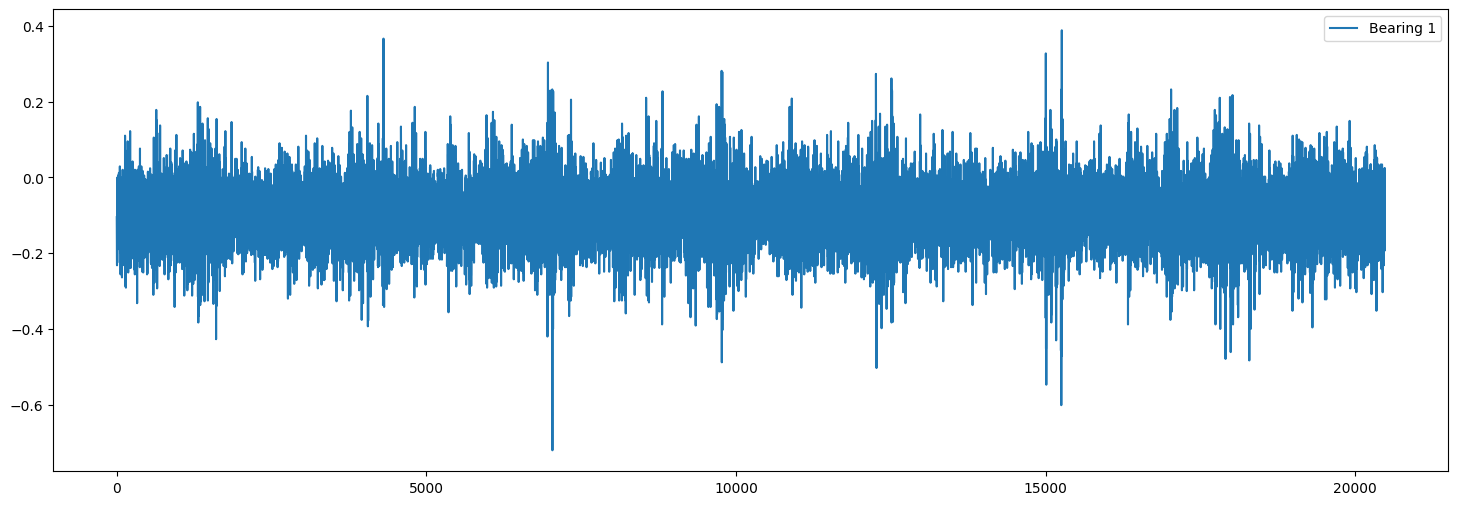

In [13]:
# Señal cruda del rodamiento 1
dataset[['Bearing 1']].plot(figsize=(18,6));

In [15]:
dataset = pd.read_csv(f'{dataset_path_1st}/2003.11.25.23.39.56', sep='\t')
dataset.columns = ['Bearing 1','Bearing 2','Bearing 3','Bearing 4','Bearing 5','Bearing 6','Bearing 7','Bearing 8']
dataset.head()

,Bearing 1,Bearing 2,Bearing 3,Bearing 4,Bearing 5,Bearing 6,Bearing 7,Bearing 8
0,-0.066,-0.068,-0.063,-0.417,-0.271,-0.107,-0.078,-0.081
1,-0.078,-0.154,-0.193,-0.122,-0.254,-0.154,0.034,-0.107
2,-0.146,-0.222,-0.320,0.037,0.205,-0.349,0.090,-0.093
3,-0.083,-0.330,-0.088,-0.176,-0.417,0.103,-0.061,-0.190
4,-0.156,-0.183,0.012,-0.247,-0.667,-0.430,-0.095,0.007


## Revisión de los archivos

A continuación se consulta la cantidad de archivos con mediciones de los sensores con el fin de determinar si es una opción factible combinar los archivos de cada prueba (1st_test, 2nd_test y 3rd_test) y graficarlos para buscar patrones.

In [16]:
# Revisión de los archivos
import os

path_1st_test = 'datos/IMS_bearing_dataset/1st_test/1st_test'
path_2nd_test = 'datos/IMS_bearing_dataset/2nd_test/2nd_test'
path_3rd_test = 'datos/IMS_bearing_dataset/3rd_test/4th_test/txt'

file_list_1st_test = os.listdir(path_1st_test)
file_list_2nd_test = os.listdir(path_2nd_test)
file_list_3rd_test = os.listdir(path_3rd_test)

num_files_1st_test = len(file_list_1st_test)
num_files_2nd_test = len(file_list_2nd_test)
num_files_3rd_test = len(file_list_3rd_test)

print(f'Number of files in {path_1st_test}: {num_files_1st_test}')
print(f'Number of files in {path_2nd_test}: {num_files_2nd_test}')
print(f'Number of files in {path_3rd_test}: {num_files_3rd_test}')


Number of files in datos/IMS_bearing_dataset/1st_test/1st_test: 2156
Number of files in datos/IMS_bearing_dataset/2nd_test/2nd_test: 984
Number of files in datos/IMS_bearing_dataset/3rd_test/4th_test/txt: 6324


Se observa que la tercera prueba fue la que recolectó mayor cantidad de archivos con 6.324, seguida de la primera prueba con 2.156 archivos de 20.000 (aproximadamente) lecturas cada uno. Debido a la gran cantidad de archivos no parece factible combinarlos para realizar las gráficas.

El gran volumen de datos hace que tampoco sea viable generar una gráfica por cada archivo. Por ello se procede a revisar los primeros y los últimos archivos de cada experimento ya que el documento README adjunto indica la presencia de fallas al final de cada experimento.

### Verificación de la longitud de cada archivo
Se procede a verificar la longitud de cada archivo, ya que en el documento [Readme Document for IMS Bearing Data.pdf](https://file.notion.so/f/f/1022c098-f574-4b46-86a3-faf147fb3f26/76e16648-6f57-4f28-9589-caa2c6149a49/Readme_Document_for_IMS_Bearing_Data.pdf?table=block&id=22603b0a-b1d2-80eb-9df2-e5344fa9474c&spaceId=1022c098-f574-4b46-86a3-faf147fb3f26&expirationTimestamp=1753948800000&signature=5eKVFHFalBteXRsy7uQgwUos4nivNGgSFkoi9WjiXdY&downloadName=Readme+Document+for+IMS+Bearing+Data.pdf) se explica que los archivos tienen una longitud aproximada de 20.000 lectura dado que se realizaron mediciones de 1 segundo a 20hz. Con la longitud de cada archivo se espera saber si se requiere hacer alguna adpación a los datos antes de usarlos para alimentar a algún modelo.

In [17]:
def obtener_longitud_archivos(ruta_carpeta):
    """
    Lee todos los archivos CSV/TSV de una carpeta y obtiene la cantidad de filas de cada uno.

    Args:
        ruta_carpeta (str): Ruta absoluta o relativa de la carpeta que contiene los archivos.

    Returns:
        pandas.DataFrame: Un DataFrame con dos columnas:
            - **archivo**: nombre del archivo.
            - **longitud**: número de filas que contiene el archivo.

    Raises:
        NotADirectoryError: Si la ruta proporcionada no es una carpeta válida.
        FileNotFoundError: Si algún archivo no puede ser encontrado al momento de lectura.
        pandas.errors.ParserError: Si el formato de algún archivo no corresponde al esperado.
    """
    if not os.path.isdir(ruta_carpeta):
        raise NotADirectoryError(f"La ruta '{ruta_carpeta}' no es una carpeta válida.")

    file_list = os.listdir(ruta_carpeta)
    if not file_list:
        raise FileNotFoundError(f"No se encontraron archivos en la carpeta '{ruta_carpeta}'.")

    file_data = []
    for file_name in file_list:
        file_path = os.path.join(ruta_carpeta, file_name)
        if not os.path.isfile(file_path):
            raise FileNotFoundError(f"El archivo '{file_path}' no existe o no es un archivo válido.")

        df = pd.read_csv(file_path, sep='\t', header=None)  # Asume separación por tabulador
        total_faltantes = df.isna().sum().sum()
        file_data.append({'archivo': file_name, 'longitud': len(df), 'faltantes': total_faltantes})

    return pd.DataFrame(file_data)



In [18]:
metadata_archivos_1st_test = obtener_longitud_archivos('datos/IMS_bearing_dataset/1st_test/1st_test')
metadata_archivos_2nd_test = obtener_longitud_archivos('datos/IMS_bearing_dataset/2nd_test/2nd_test')
metadata_archivos_3rd_test = obtener_longitud_archivos('datos/IMS_bearing_dataset/3rd_test/4th_test/txt')


In [19]:
print(f"Longitud de archivos en 1st_test: {metadata_archivos_1st_test['longitud'].unique()}")
print(f"Datos faltantes en 1st_test: {metadata_archivos_1st_test['faltantes'].sum()}")

print()
print(f"Longitud de archivos en 2nd_test: {metadata_archivos_2nd_test['longitud'].unique()}")
print(f"Datos faltantes en 2nd_test: {metadata_archivos_2nd_test['faltantes'].sum()}")

print()
print(f"Longitud de archivos en 3rd_test: {metadata_archivos_3rd_test['longitud'].unique()}")
print(f"Datos faltantes en 3rd_test: {metadata_archivos_3rd_test['faltantes'].sum()}")

Longitud de archivos en 1st_test: [20480]
Datos faltantes en 1st_test: 0

Longitud de archivos en 2nd_test: [20480]
Datos faltantes en 2nd_test: 0

Longitud de archivos en 3rd_test: [20480]
Datos faltantes en 3rd_test: 0


Se pudo validar que todos los archivos tienen una longitud de 20480 mediciones.



# Gráficas de los primeros archivos de cada prueba

Ya se observó que cada prueba recolectó una basta cantidad de archivos con mediciones por lo que se plantea ahora graficar sólo los primeros archivos de cada prueba correspondientes a las etapas finales de los experimentos.

Con este análisis se espera observar la forma de señal de las mediciones realizadas en los rodamientos. Al inicio de los experimentos los rodamientos se encontraban en óptimas condiciones, por ello las siguientes gráficas muestran la operación normal de los rodamientos.

In [20]:
# Impresión del nombre de los últimos archivos de cada prueba
copy_files_1st_test = file_list_1st_test.copy()
copy_files_2nd_test = file_list_2nd_test.copy()
copy_files_3rd_test = file_list_3rd_test.copy()

copy_files_1st_test.sort()
copy_files_2nd_test.sort()
copy_files_3rd_test.sort()

print(f"Primer archivo en 1st_test: {copy_files_1st_test[0]}")
print(f"Primer archivo en 2nd_test: {copy_files_2nd_test[0]}")
print(f"Primer archivo en 3rd_test: {copy_files_3rd_test[0]}")


Primer archivo en 1st_test: 2003.10.22.12.06.24
Primer archivo en 2nd_test: 2004.02.12.10.32.39
Primer archivo en 3rd_test: 2004.03.04.09.27.46


## Gráfica de 1st_test

In [21]:
dataset = pd.read_csv(f'{path_1st_test}/2003.10.22.12.06.24', sep='\t')
dataset.columns = ['Canal 1','Canal 2','Canal 3','Canal 4','Canal 5','Canal 6','Canal 7','Canal 8']
dataset.head()


,Canal 1,Canal 2,Canal 3,Canal 4,Canal 5,Canal 6,Canal 7,Canal 8
0,-0.105,-0.017,-0.164,-0.183,-0.049,0.029,-0.115,-0.122
1,-0.183,-0.098,-0.195,-0.125,-0.005,-0.007,-0.171,-0.071
2,-0.178,-0.161,-0.159,-0.178,-0.100,-0.115,-0.112,-0.078
3,-0.208,-0.129,-0.261,-0.098,-0.151,-0.205,-0.063,-0.066
4,-0.232,-0.061,-0.281,-0.125,0.046,-0.088,-0.078,-0.078


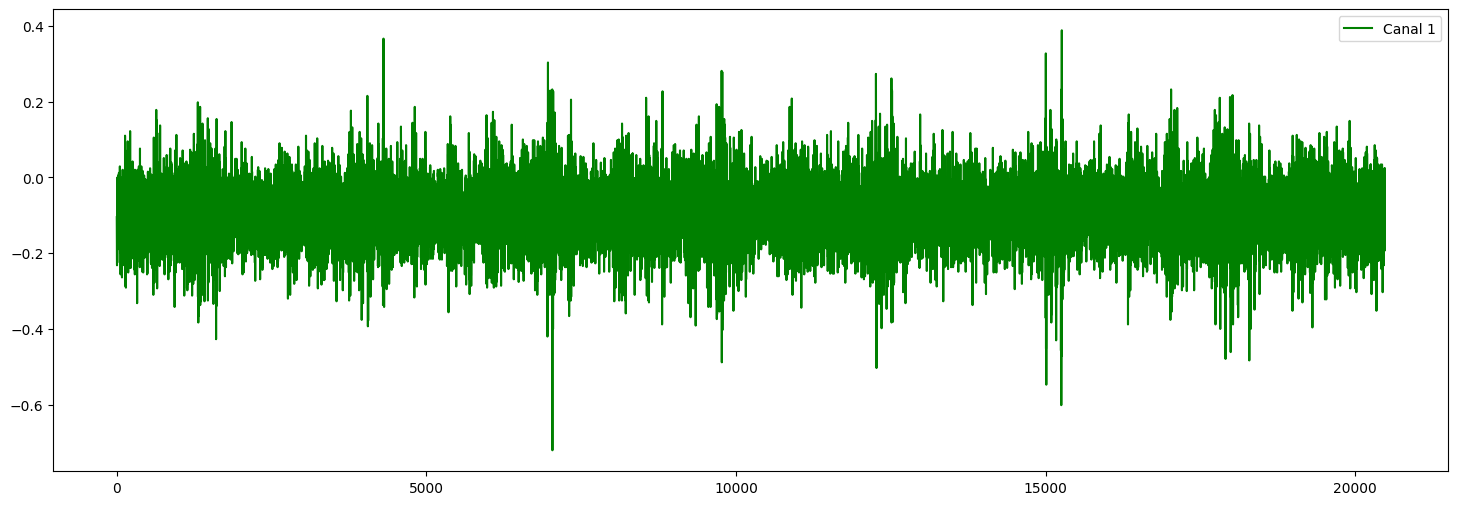

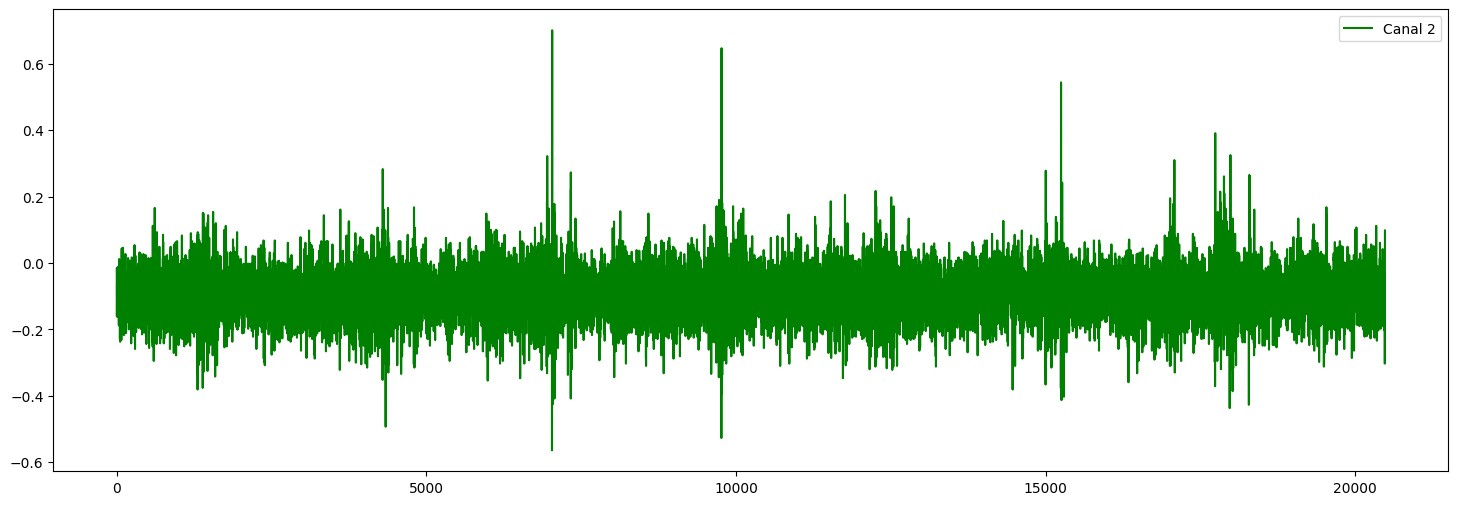

In [22]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 1
dataset[['Canal 1']].plot(figsize=(18,6), color='green');
dataset[['Canal 2']].plot(figsize=(18,6), color='green');

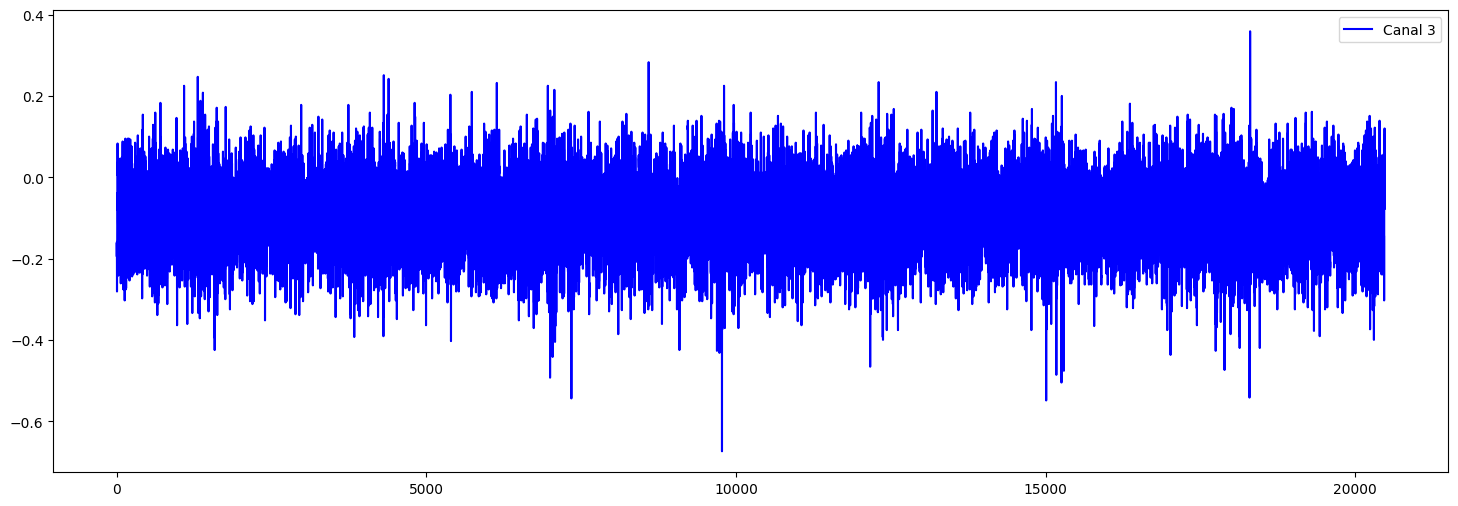

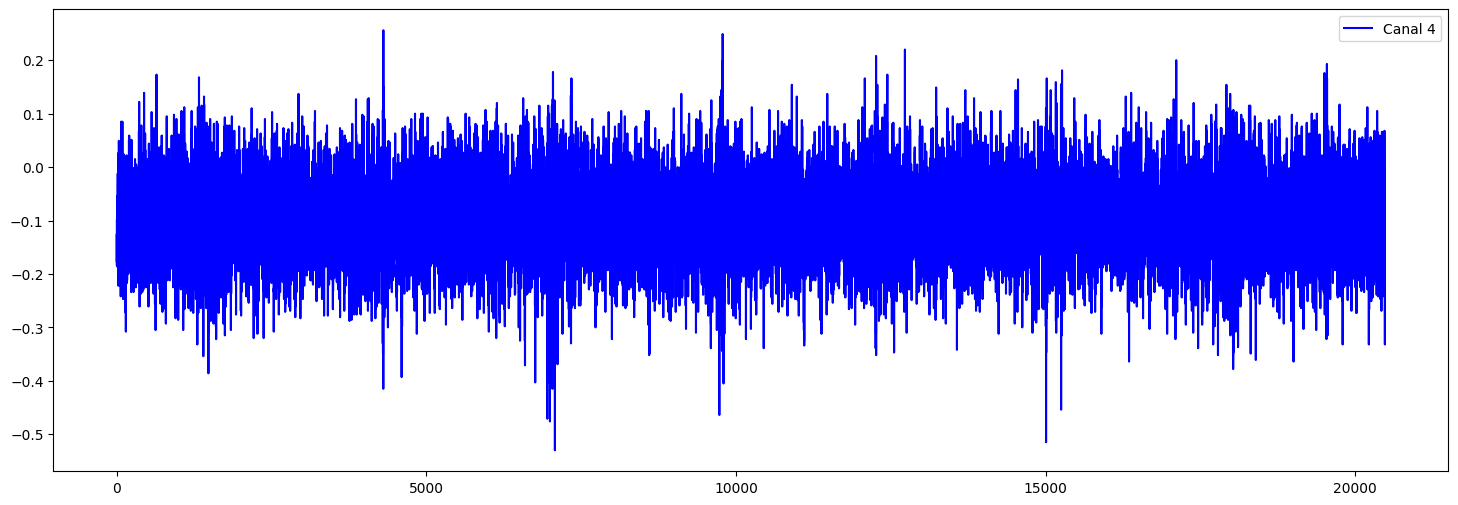

In [23]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 2
dataset[['Canal 3']].plot(figsize=(18,6), color='blue');
dataset[['Canal 4']].plot(figsize=(18,6), color='blue');

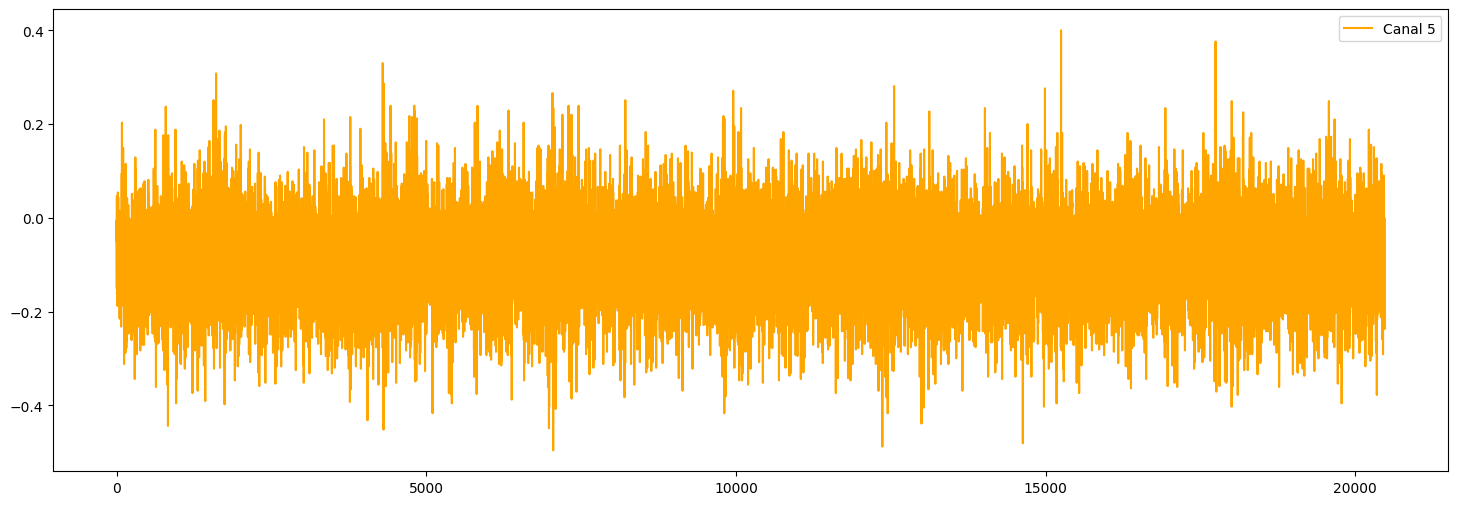

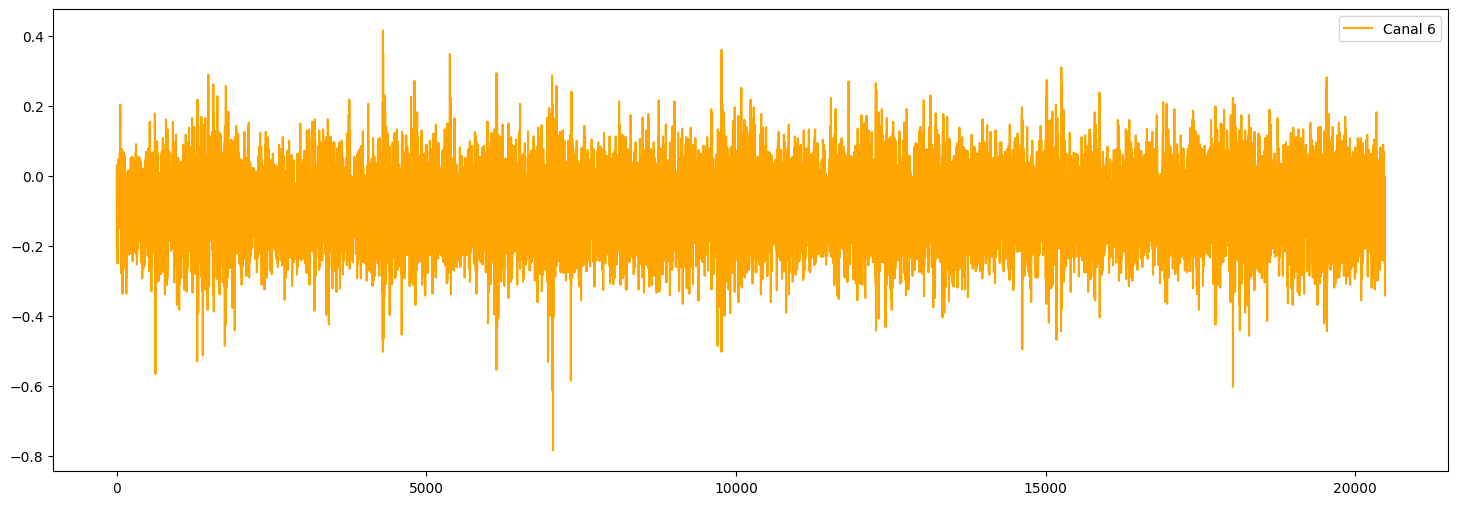

In [24]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 3 (Falla en la pista interior)
dataset[['Canal 5']].plot(figsize=(18,6), color='orange');
dataset[['Canal 6']].plot(figsize=(18,6), color='orange');

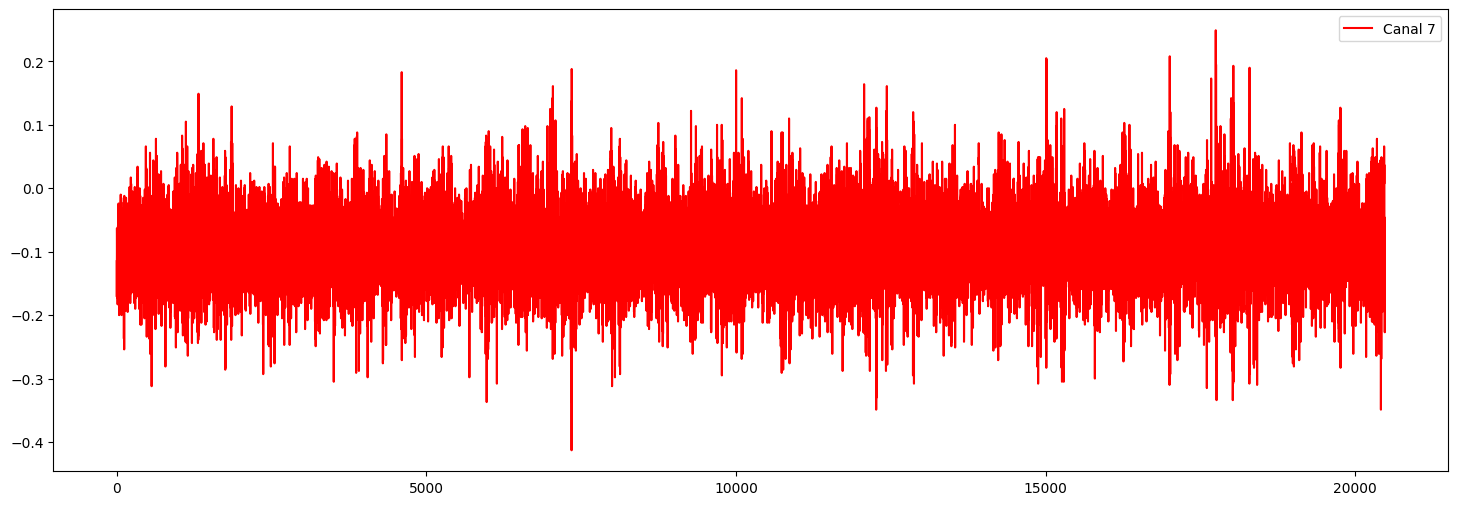

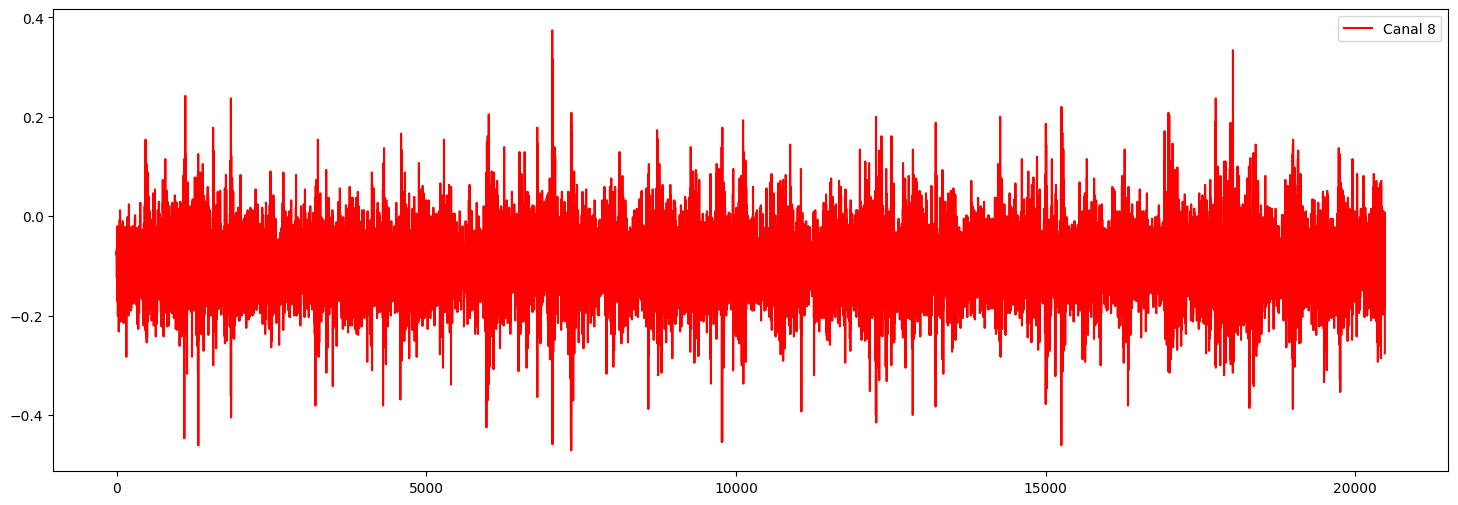

In [25]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 4 (defecto en el elemento rodante )
dataset[['Canal 7']].plot(figsize=(18,6), color='red');
dataset[['Canal 8']].plot(figsize=(18,6), color='red');

## Gráfica de 2nd_test

* Contienen 4 sensores montados en 4 rodamientos
* Al final del experimento  el rodamiento 1 presentó una falla en la pista exterior.

In [26]:
pd.read_csv(f'{path_2nd_test}/2004.02.12.10.32.39', sep='\t')

,-0.049,-0.071,-0.132,-0.010
0,-0.042,-0.073,-0.007,-0.105
1,0.015,0.000,0.007,0.000
2,-0.051,0.020,-0.002,0.100
3,-0.107,0.010,0.127,0.054
4,-0.078,-0.212,0.042,-0.044
...,...,...,...,...
20474,0.049,-0.051,-0.039,-0.044
20475,0.037,0.061,0.115,0.007
20476,-0.012,0.007,0.056,-0.007
20477,-0.012,0.093,0.017,-0.044


In [27]:
dataset = pd.read_csv(f'{path_2nd_test}/2004.02.12.10.32.39', sep='\t')
dataset.columns = ['Canal 1','Canal 2','Canal 3','Canal 4']
dataset.head()


,Canal 1,Canal 2,Canal 3,Canal 4
0,-0.042,-0.073,-0.007,-0.105
1,0.015,0.000,0.007,0.000
2,-0.051,0.020,-0.002,0.100
3,-0.107,0.010,0.127,0.054
4,-0.078,-0.212,0.042,-0.044


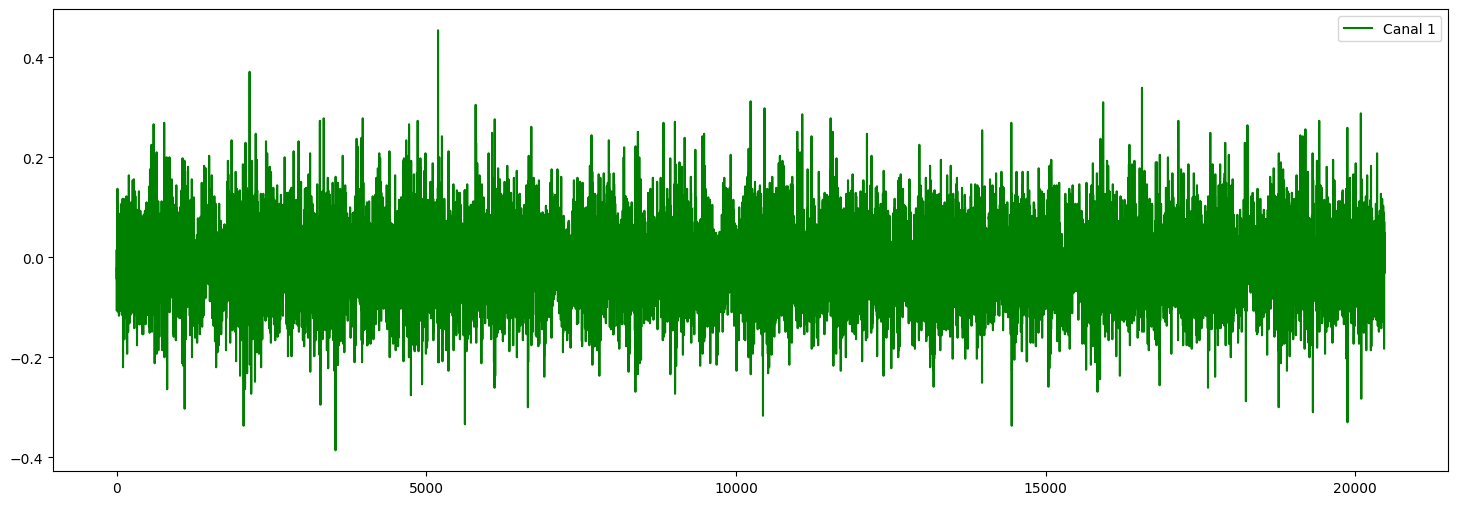

In [28]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 1 (Falla en la pista exterior)
dataset[['Canal 1']].plot(figsize=(18,6), color='green');

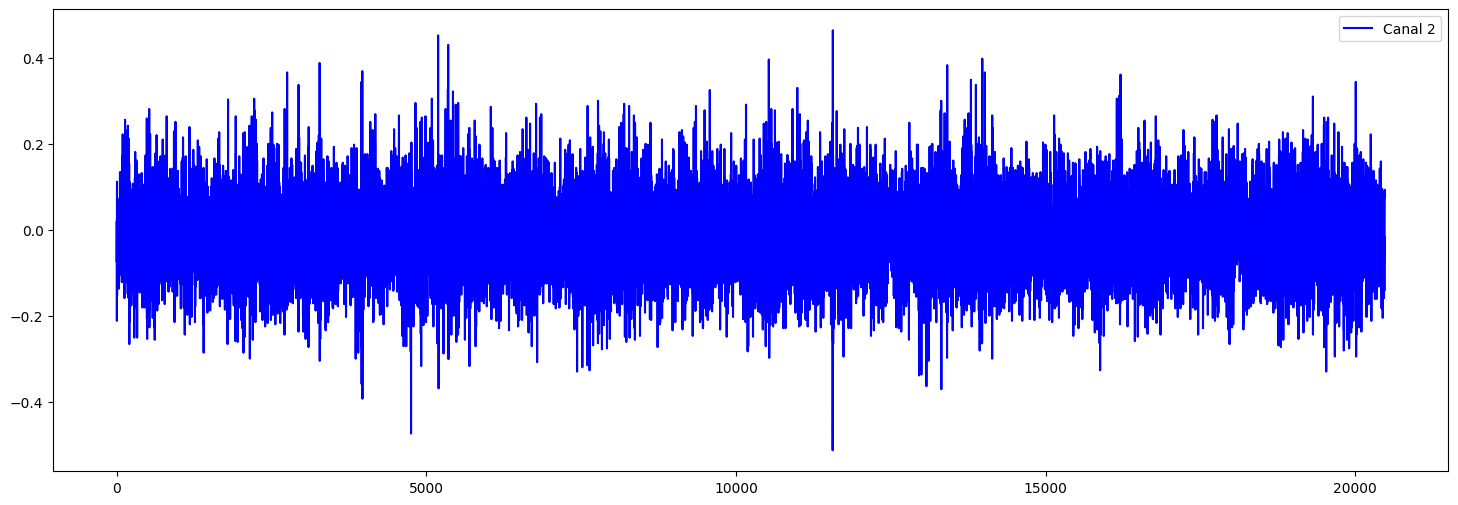

In [29]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 2
dataset[['Canal 2']].plot(figsize=(18,6), color='blue');

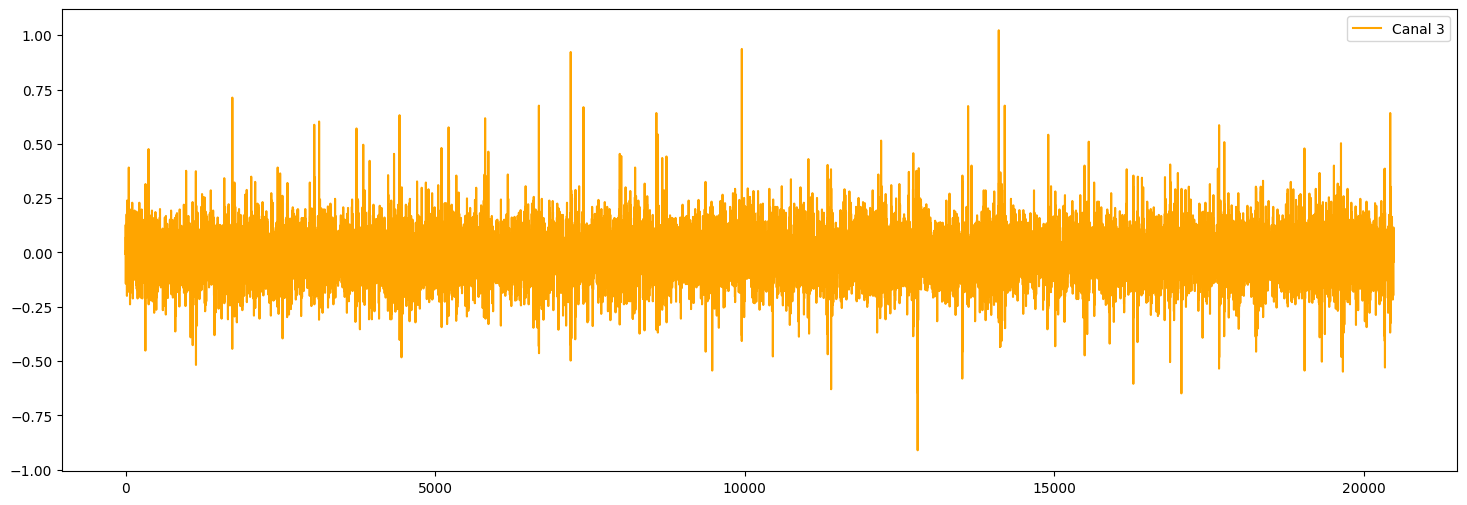

In [30]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 3
dataset[['Canal 3']].plot(figsize=(18,6), color='orange');

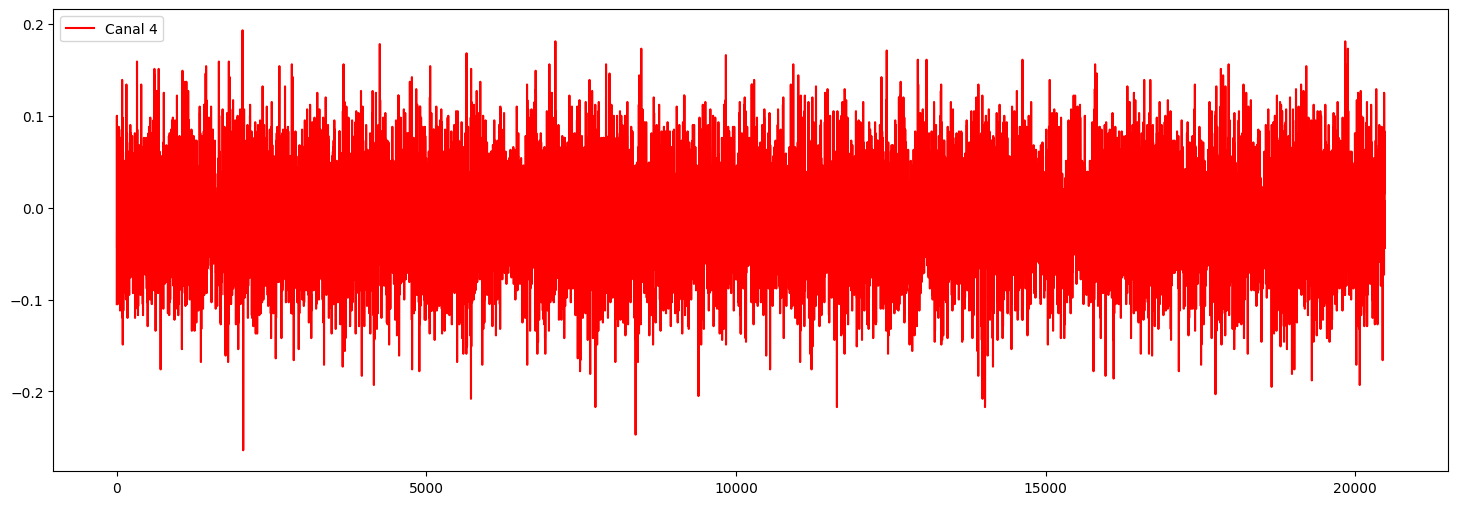

In [31]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 4
dataset[['Canal 4']].plot(figsize=(18,6), color='red');

## Gráfica de 3rd_test


In [32]:
dataset = pd.read_csv(f'{path_3rd_test}/2004.03.04.09.27.46', sep='\t')
dataset.columns = ['Canal 1','Canal 2','Canal 3','Canal 4']
dataset.head()


,Canal 1,Canal 2,Canal 3,Canal 4
0,0.103,0.083,-0.061,-0.012
1,0.095,-0.039,-0.007,0.039
2,0.000,0.110,0.022,-0.002
3,0.005,0.154,-0.127,-0.020
4,0.010,0.027,-0.007,-0.039


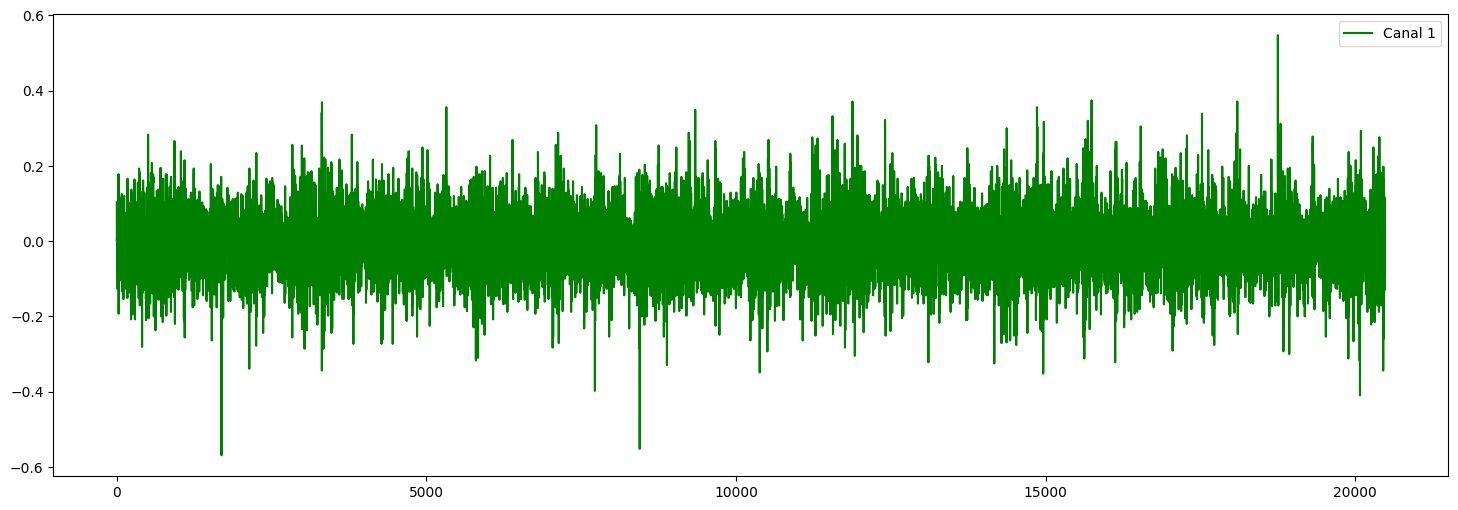

In [33]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 1 (Falla en la pista exterior)
dataset[['Canal 1']].plot(figsize=(18,6), color='green');

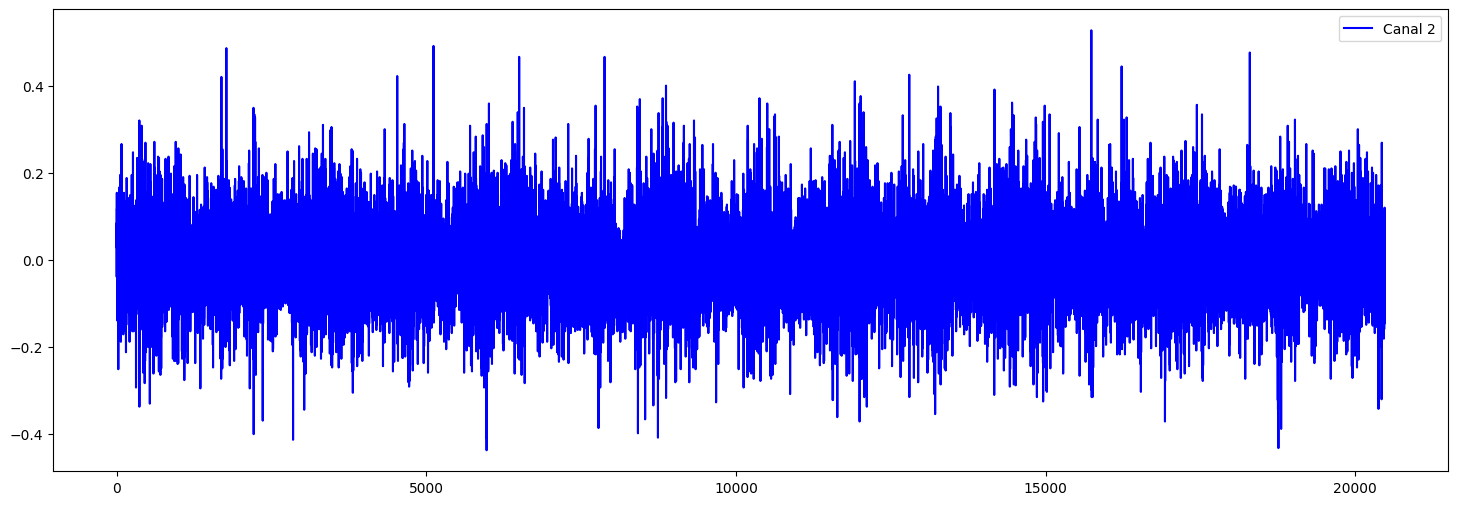

In [34]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 2
dataset[['Canal 2']].plot(figsize=(18,6), color='blue');

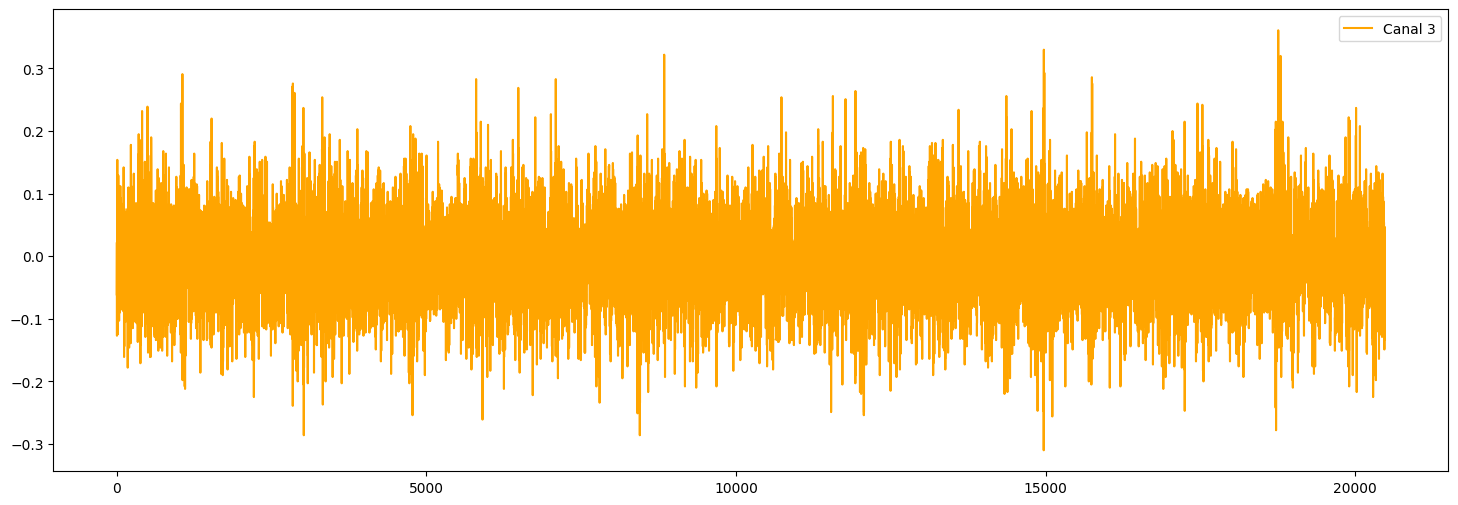

In [35]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 3 (falla en la pista exterior)
dataset[['Canal 3']].plot(figsize=(18,6), color='orange');

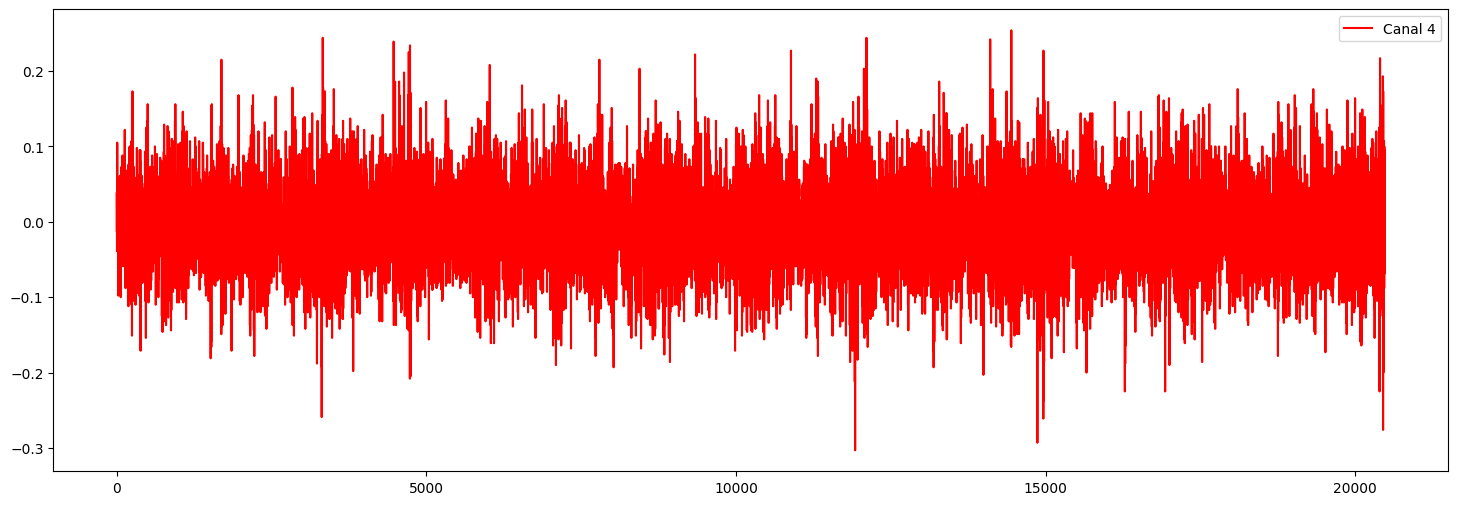

In [36]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 4
dataset[['Canal 4']].plot(figsize=(18,6), color='red');

## Análisis

Las gráficas de los 3 experimentos tienen formas de señales muy variadas con picos muy marcados.

# Gráficas de los últimos archivos de cada prueba

Ya se observó que cada prueba recolectó una basta cantidad de archivos con mediciones por lo que se plantea ahora graficar sólo los últimos archivos de cada prueba correspondientes a las etapas finales de los experimentos.

Se espera observar las fallas descritas en el archivo [Readme Document for IMS Bearing Data.pdf](https://file.notion.so/f/f/1022c098-f574-4b46-86a3-faf147fb3f26/76e16648-6f57-4f28-9589-caa2c6149a49/Readme_Document_for_IMS_Bearing_Data.pdf?table=block&id=22603b0a-b1d2-80eb-9df2-e5344fa9474c&spaceId=1022c098-f574-4b46-86a3-faf147fb3f26&expirationTimestamp=1753948800000&signature=5eKVFHFalBteXRsy7uQgwUos4nivNGgSFkoi9WjiXdY&downloadName=Readme+Document+for+IMS+Bearing+Data.pdf) adjunto al conjunto de datos:
* **1st_test**: Falla en la pista interior del rodamiento 3 y un defecto en el elemento rodante del rodamiento 4.
* **2nd_test**: Falla en la pista exterior del rodamiento 1.
* **3rd_test**: Falla en la pista exterior del rodamiento 3.

In [37]:
# Impresión del nombre de los últimos archivos de cada prueba
copy_files_1st_test = file_list_1st_test.copy()
copy_files_2nd_test = file_list_2nd_test.copy()
copy_files_3rd_test = file_list_3rd_test.copy()

copy_files_1st_test.sort()
copy_files_2nd_test.sort()
copy_files_3rd_test.sort()

print(f"Último archivo en 1st_test: {copy_files_1st_test[-1]}")
print(f"Último archivo en 2nd_test: {copy_files_2nd_test[-1]}")
print(f"Último archivo en 3rd_test: {copy_files_3rd_test[-1]}")


Último archivo en 1st_test: 2003.11.25.23.39.56
Último archivo en 2nd_test: 2004.02.19.06.22.39
Último archivo en 3rd_test: 2004.04.18.02.42.55


## Gráfica de 1st_test


* Contienen 8 sensores montados en 4 rodamientos:
  * Rodamiento 1 tiene los sensores 1 y 2
  * Rodamiento 2 tiene los sensores 3 y 4
  * Rodamiento 3 tiene los sensores 5 y 6
  * Rodamiento 4 tiene los sensores 7 y 8
* Al final de esta prueba el rodamiento 3 presentó una falla en la pista interior y el rodamiento 4 un defecto en el elemento rodante.

In [38]:
dataset = pd.read_csv(f'{path_1st_test}/2003.11.25.23.39.56', sep='\t')
dataset.columns = ['Canal 1','Canal 2','Canal 3','Canal 4','Canal 5','Canal 6','Canal 7','Canal 8']
dataset.head()


,Canal 1,Canal 2,Canal 3,Canal 4,Canal 5,Canal 6,Canal 7,Canal 8
0,-0.066,-0.068,-0.063,-0.417,-0.271,-0.107,-0.078,-0.081
1,-0.078,-0.154,-0.193,-0.122,-0.254,-0.154,0.034,-0.107
2,-0.146,-0.222,-0.320,0.037,0.205,-0.349,0.090,-0.093
3,-0.083,-0.330,-0.088,-0.176,-0.417,0.103,-0.061,-0.190
4,-0.156,-0.183,0.012,-0.247,-0.667,-0.430,-0.095,0.007


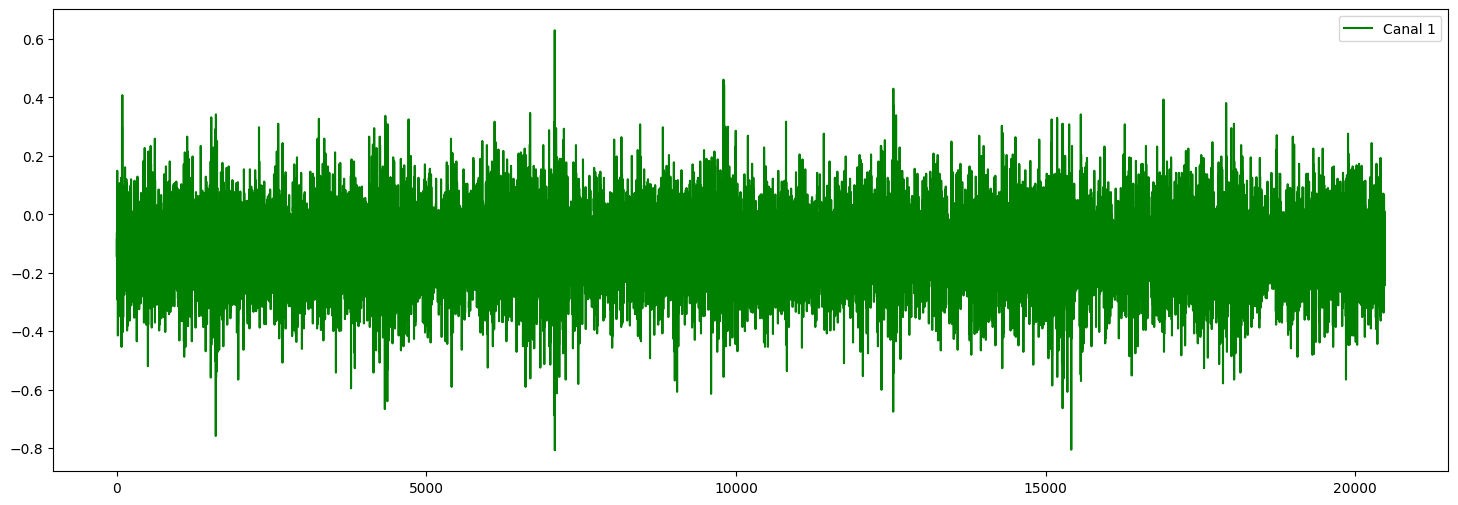

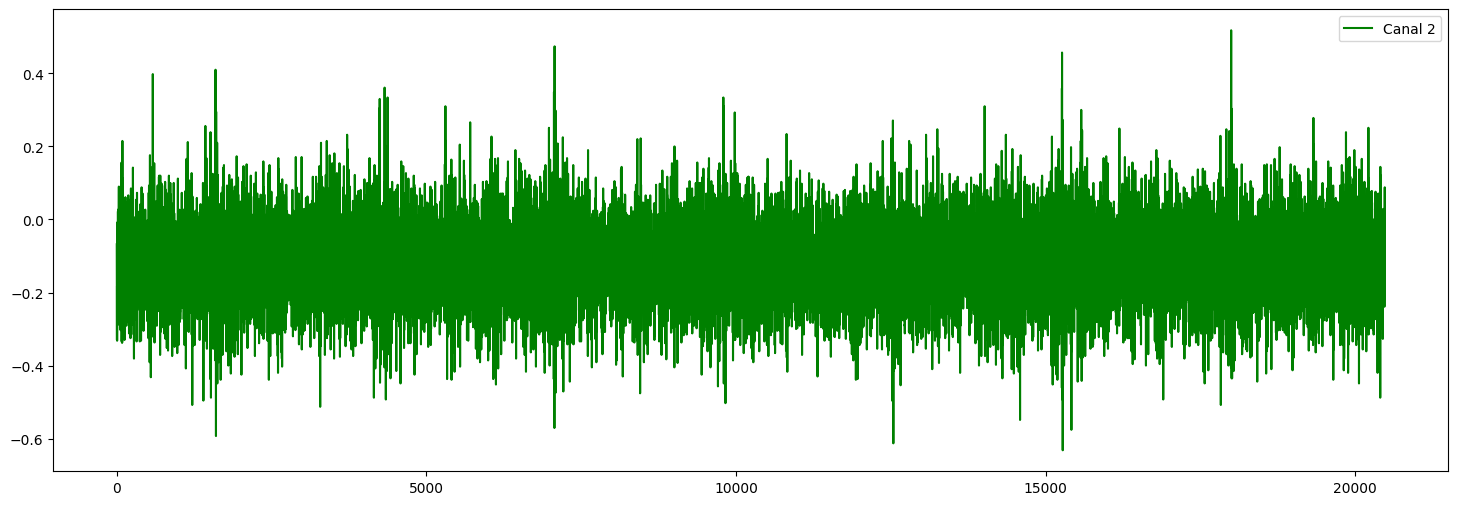

In [39]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 1
dataset[['Canal 1']].plot(figsize=(18,6), color='green');
dataset[['Canal 2']].plot(figsize=(18,6), color='green');

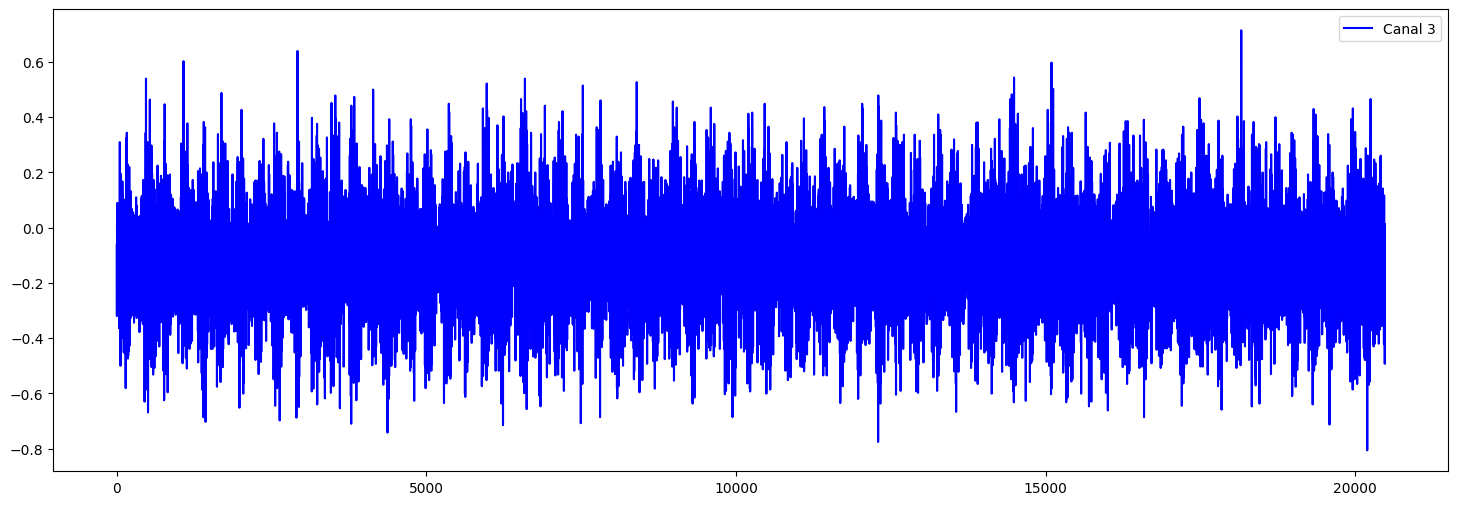

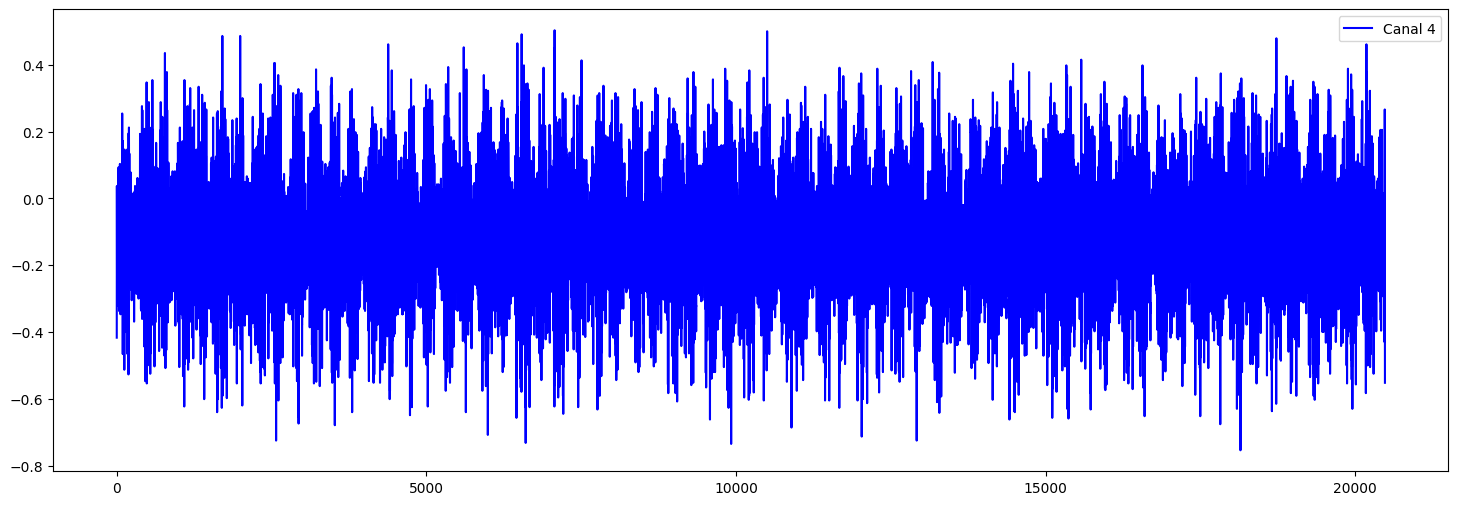

In [40]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 2
dataset[['Canal 3']].plot(figsize=(18,6), color='blue');
dataset[['Canal 4']].plot(figsize=(18,6), color='blue');

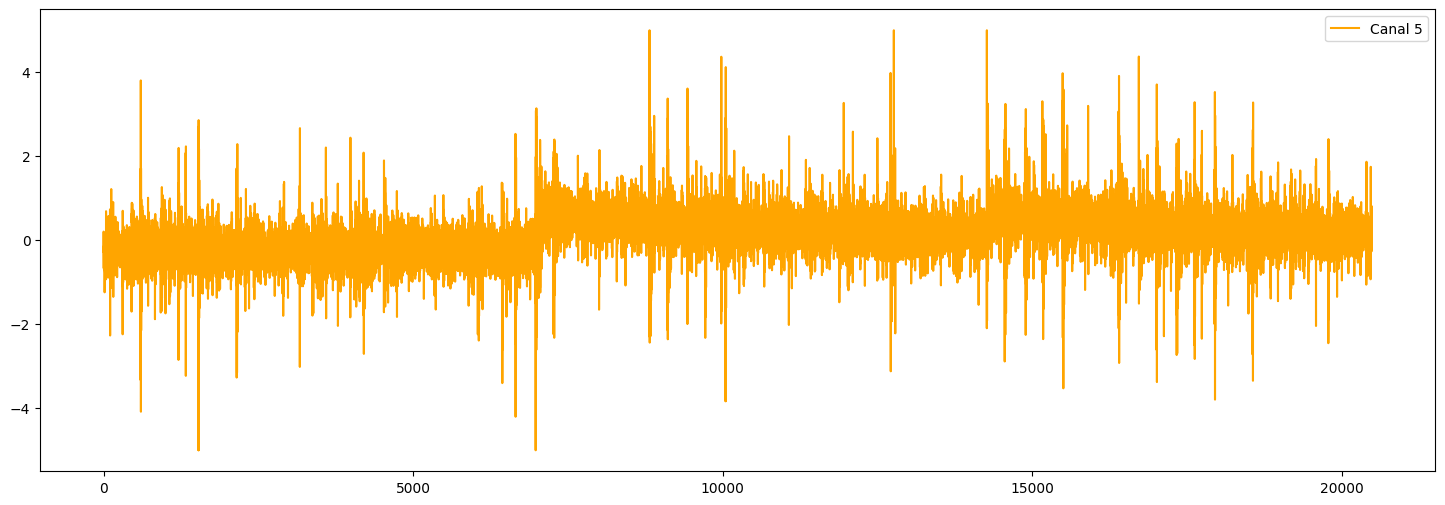

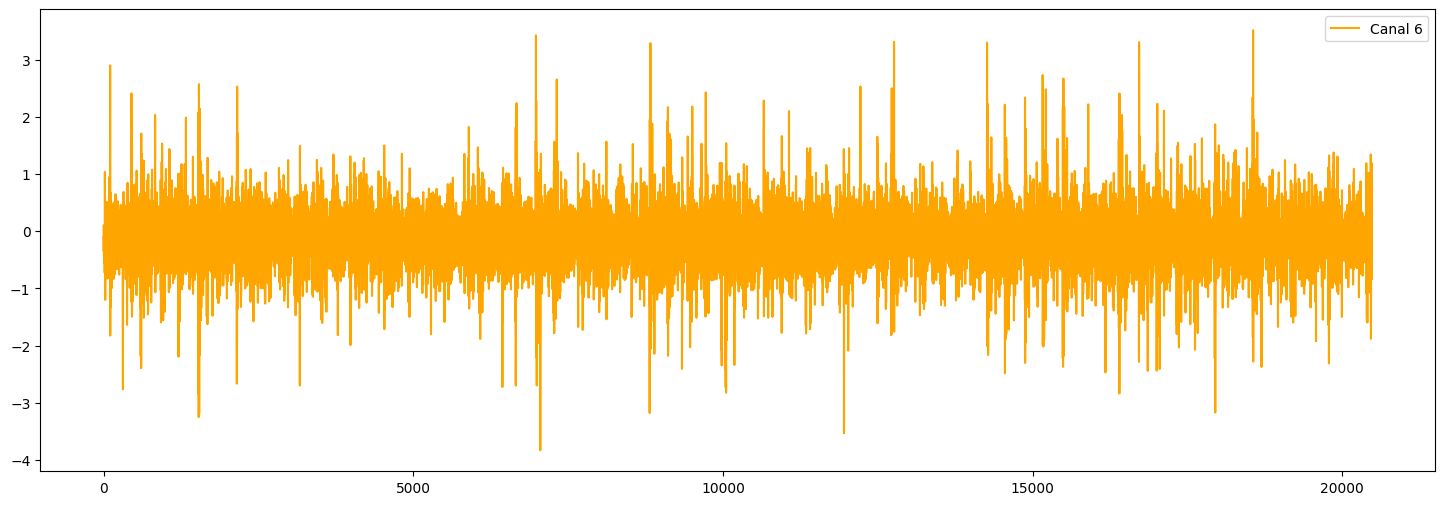

In [41]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 3 (Falla en la pista interior)
dataset[['Canal 5']].plot(figsize=(18,6), color='orange');
dataset[['Canal 6']].plot(figsize=(18,6), color='orange');

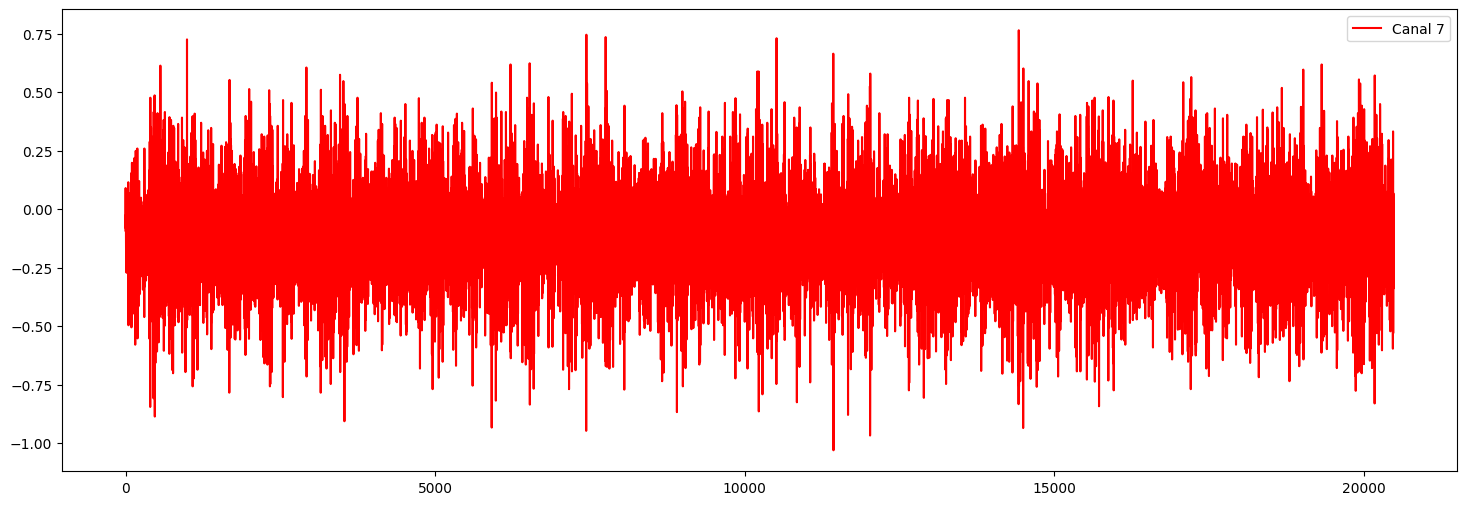

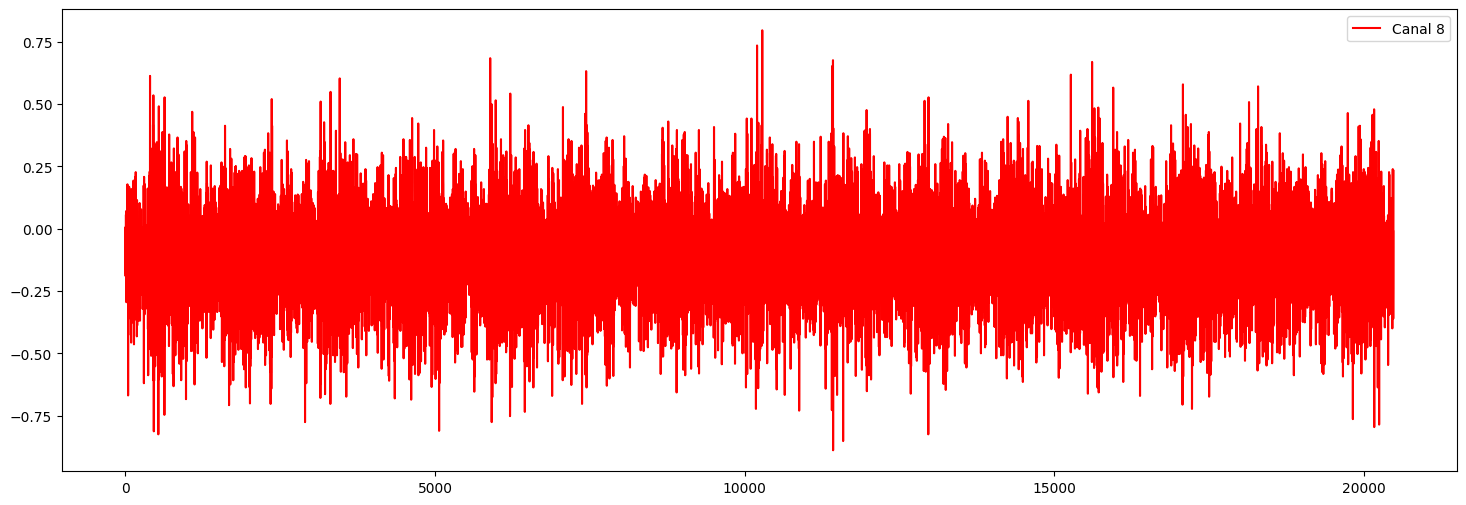

In [42]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 4 (defecto en el elemento rodante )
dataset[['Canal 7']].plot(figsize=(18,6), color='red');
dataset[['Canal 8']].plot(figsize=(18,6), color='red');

## Gráfica de 2nd_test

* Contienen 4 sensores montados en 4 rodamientos
* Al final del experimento  el rodamiento 1 presentó una falla en la pista exterior.

In [43]:
pd.read_csv(f'{path_2nd_test}/2004.02.19.06.22.39', sep='\t')

,-0.002,-0.002.1,-0.002.2,-0.002.3
0,-0.002,-0.002,0.000,-0.002
1,-0.002,-0.002,-0.002,0.000
2,-0.002,-0.002,-0.002,0.000
3,0.000,-0.002,-0.002,-0.002
4,-0.002,-0.002,-0.002,0.000
...,...,...,...,...
20474,-0.002,-0.002,-0.002,-0.002
20475,-0.002,-0.002,0.000,-0.002
20476,-0.002,0.000,0.000,-0.002
20477,-0.002,-0.002,0.000,-0.002


In [44]:
dataset = pd.read_csv(f'{path_2nd_test}/2004.02.19.06.22.39', sep='\t')
dataset.columns = ['Canal 1','Canal 2','Canal 3','Canal 4']
dataset.head()


,Canal 1,Canal 2,Canal 3,Canal 4
0,-0.002,-0.002,0.000,-0.002
1,-0.002,-0.002,-0.002,0.000
2,-0.002,-0.002,-0.002,0.000
3,0.000,-0.002,-0.002,-0.002
4,-0.002,-0.002,-0.002,0.000


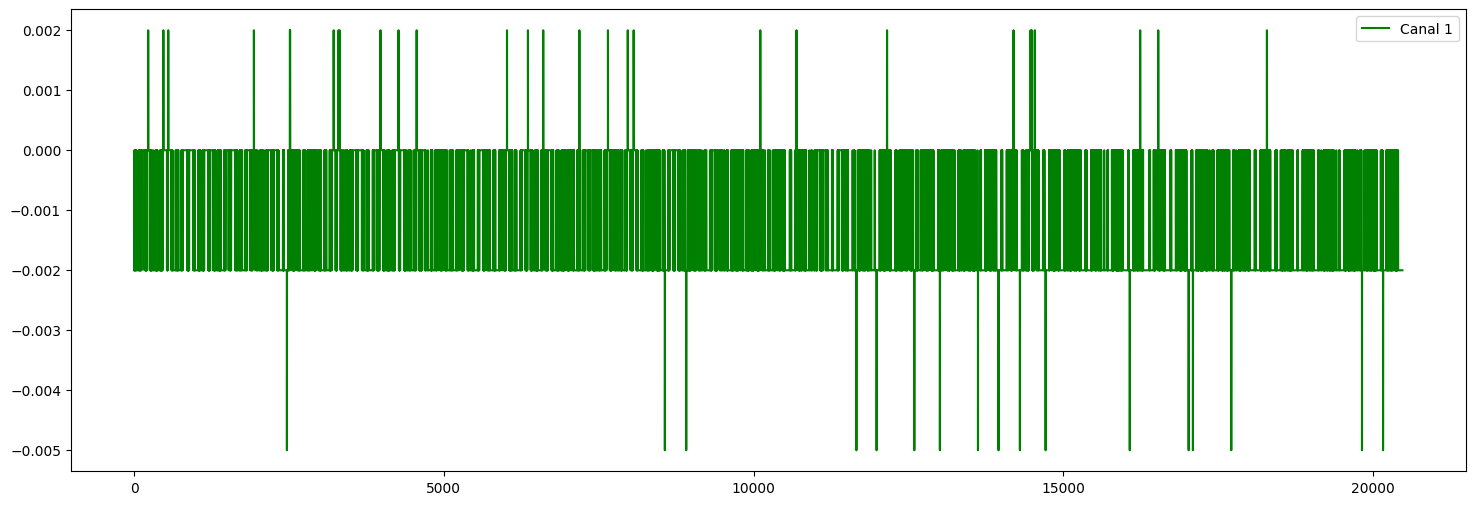

In [45]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 1 (Falla en la pista exterior)
dataset[['Canal 1']].plot(figsize=(18,6), color='green');

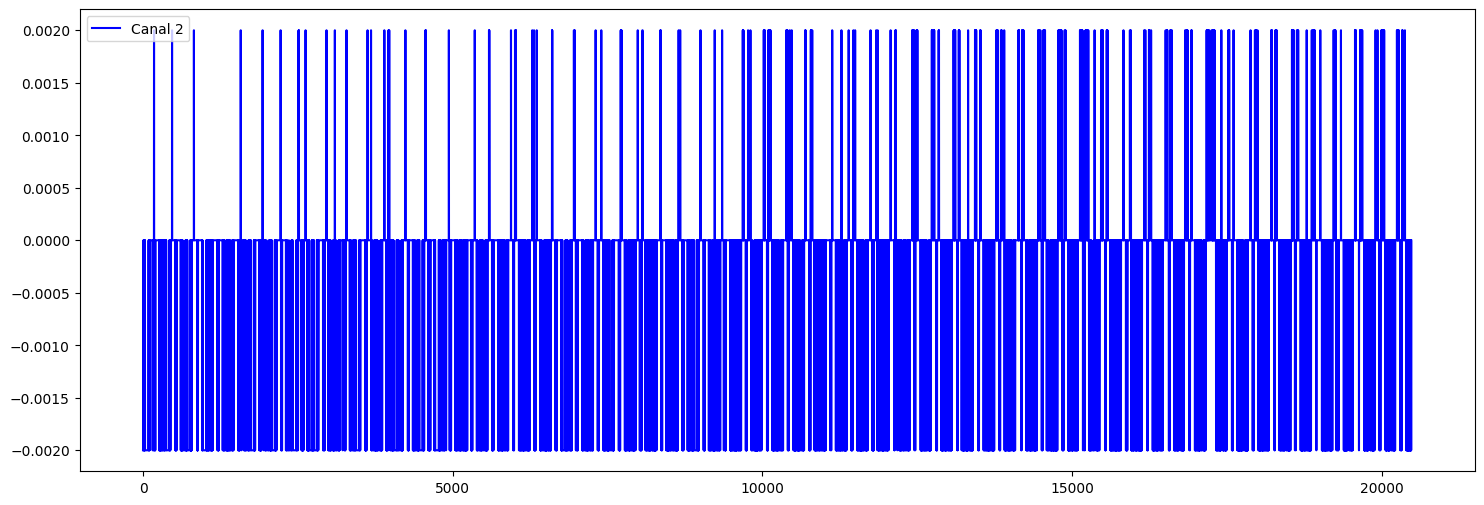

In [46]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 2
dataset[['Canal 2']].plot(figsize=(18,6), color='blue');

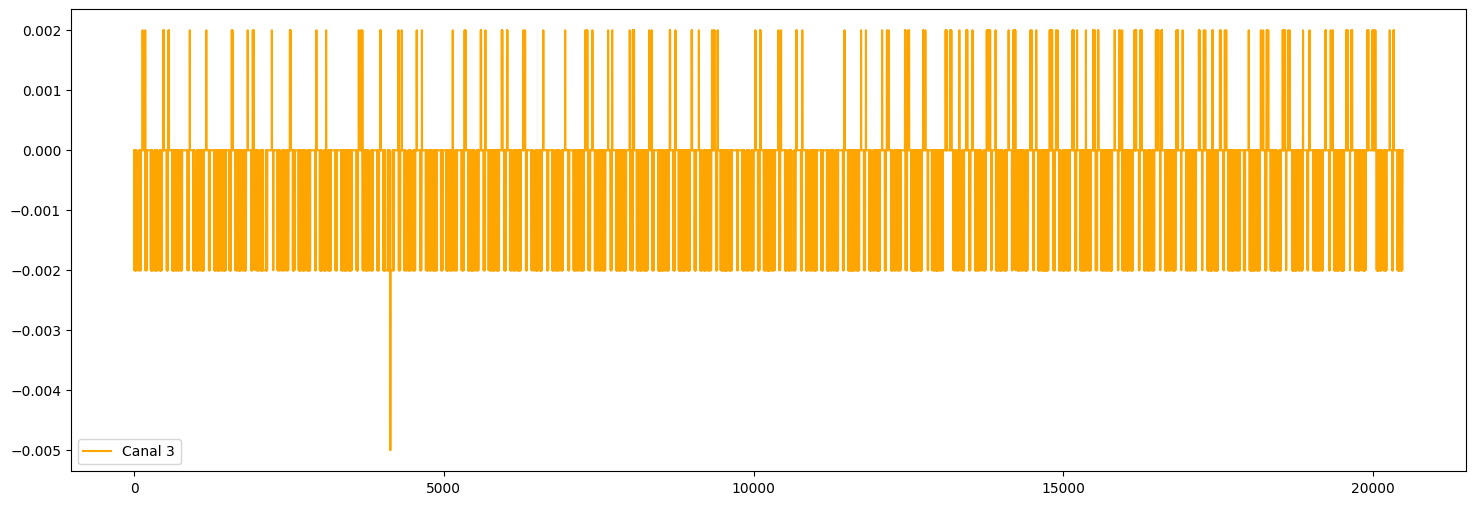

In [47]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 3
dataset[['Canal 3']].plot(figsize=(18,6), color='orange');

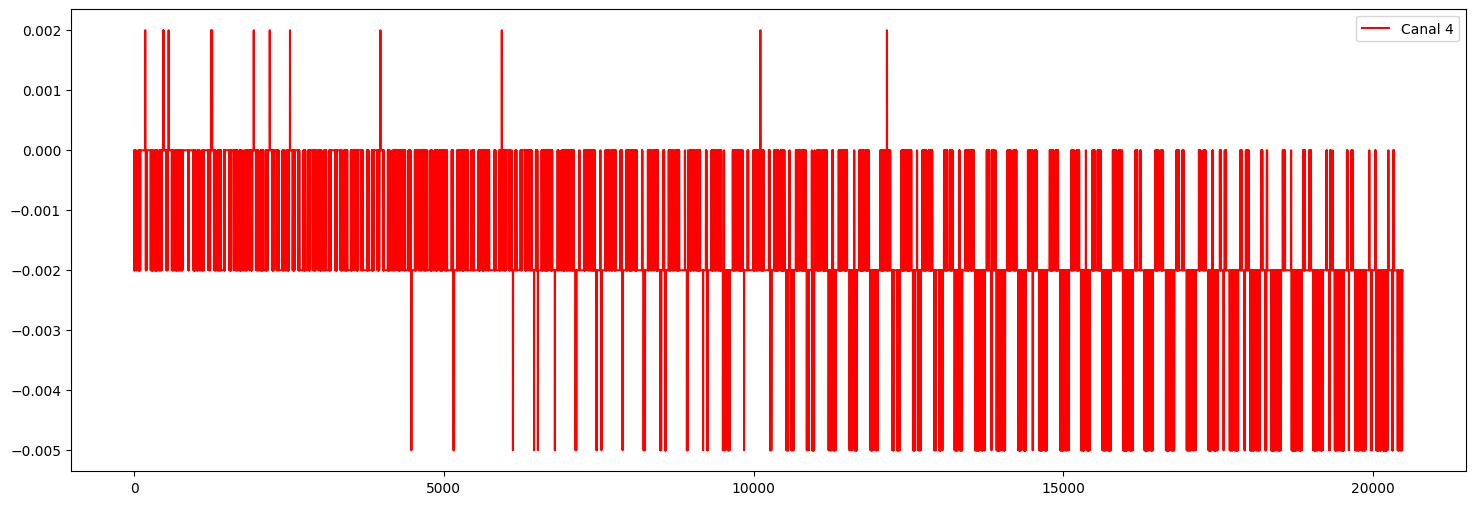

In [48]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 4
dataset[['Canal 4']].plot(figsize=(18,6), color='red');

## Gráfica de 3rd_test

* Contienen 4 sensores montados en 4 rodamientos

In [49]:
dataset = pd.read_csv(f'{path_3rd_test}/2004.04.18.02.42.55', sep='\t')
dataset.columns = ['Canal 1','Canal 2','Canal 3','Canal 4']
dataset.head()


,Canal 1,Canal 2,Canal 3,Canal 4
0,0.002,0.002,0.002,0.002
1,0.002,0.002,0.005,0.002
2,0.000,0.002,0.002,0.002
3,0.000,0.002,0.005,0.002
4,0.000,0.000,0.002,0.005


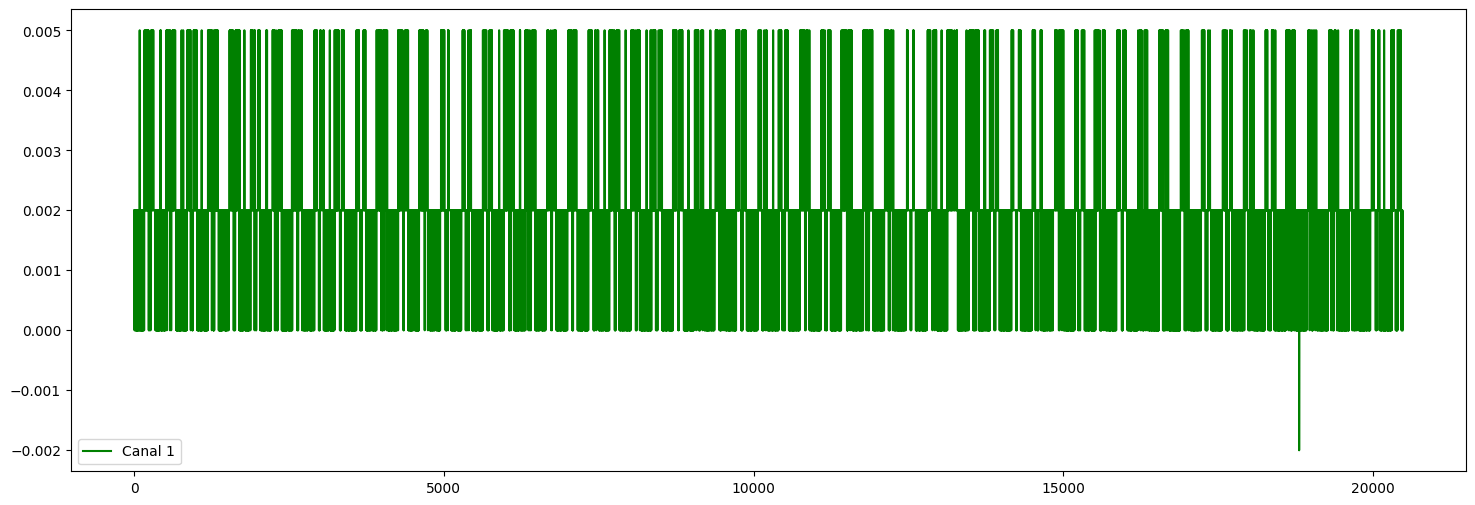

In [50]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 1 (Falla en la pista exterior)
dataset[['Canal 1']].plot(figsize=(18,6), color='green');

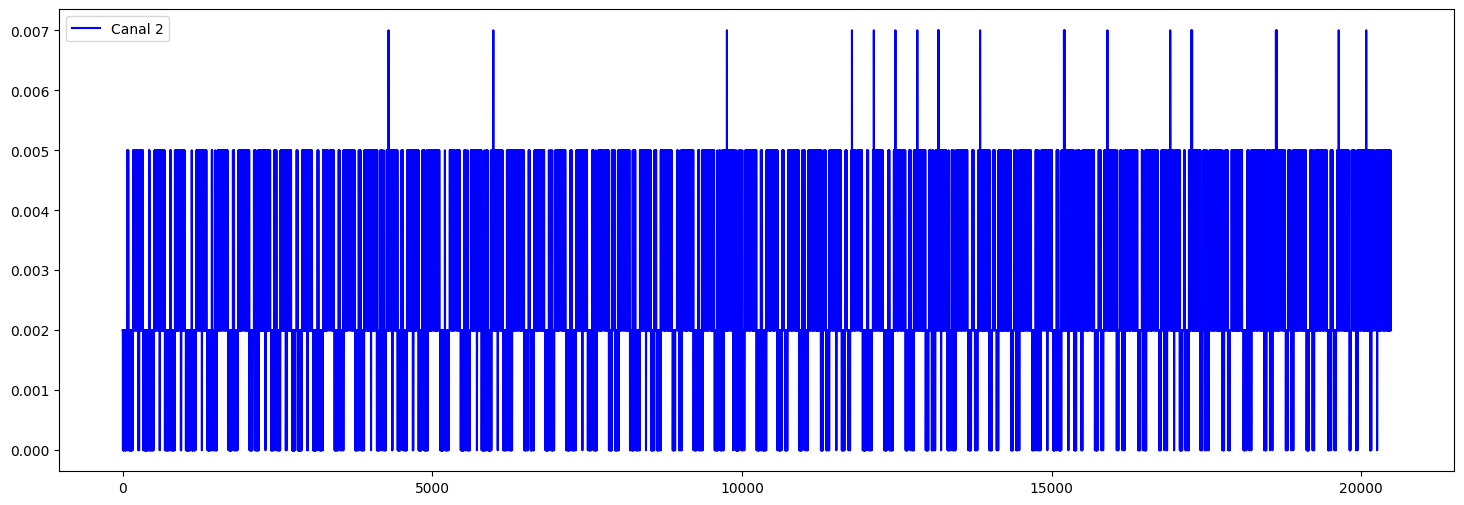

In [51]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 2
dataset[['Canal 2']].plot(figsize=(18,6), color='blue');

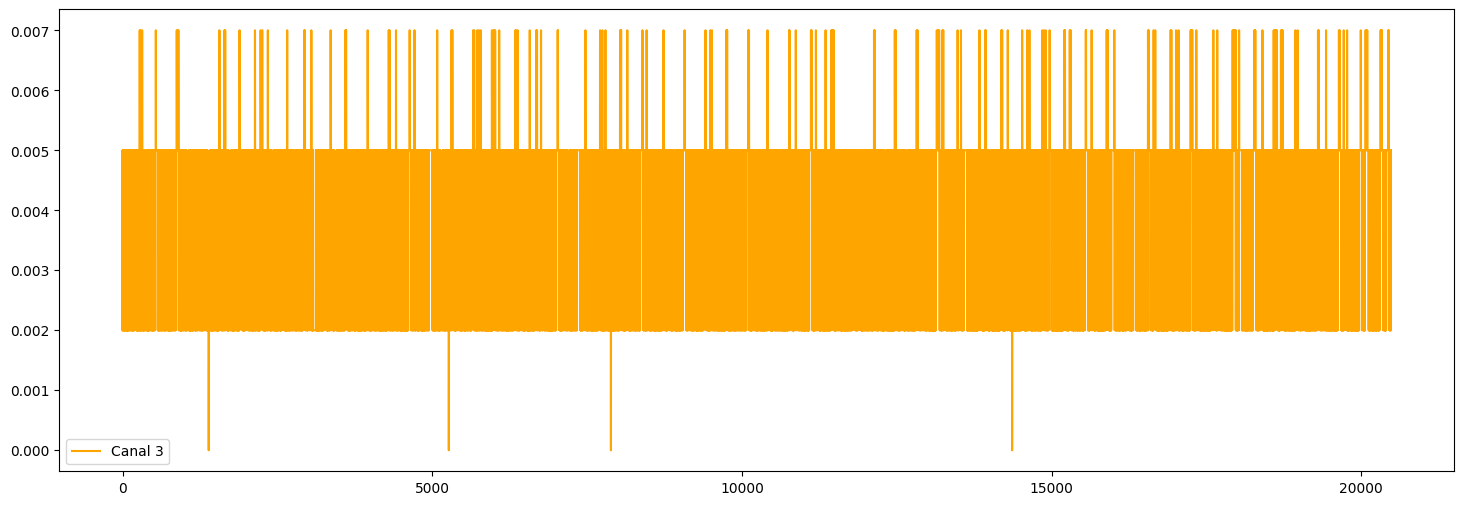

In [52]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 3 (falla en la pista exterior)
dataset[['Canal 3']].plot(figsize=(18,6), color='orange');

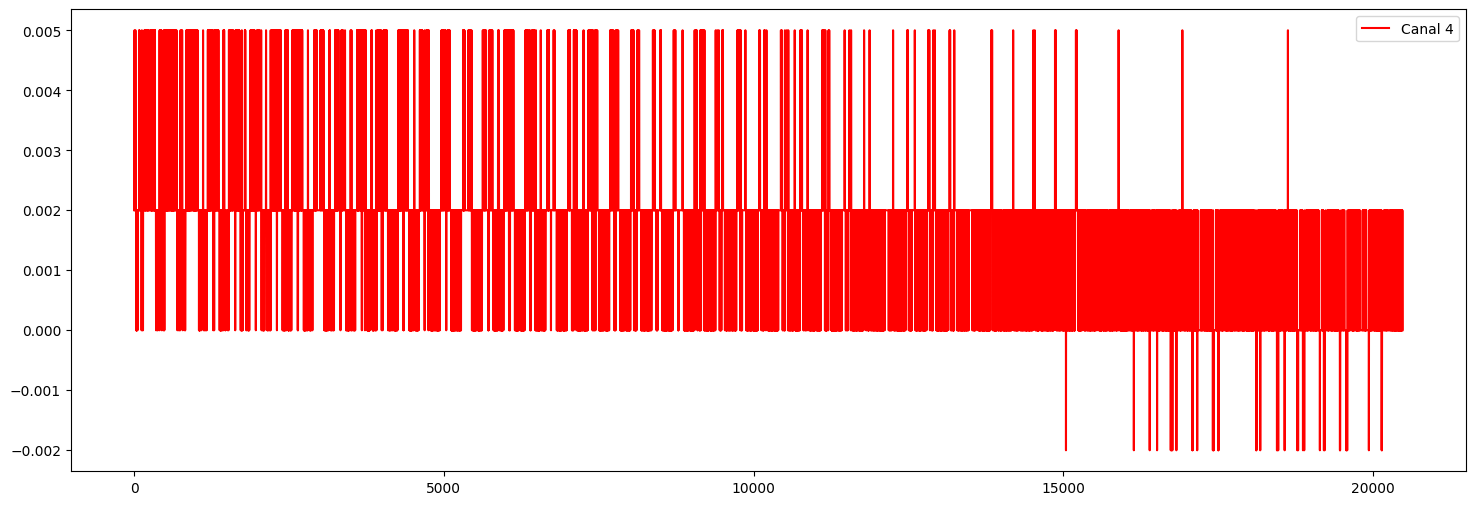

In [53]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 4
dataset[['Canal 4']].plot(figsize=(18,6), color='red');

## Análisis

Las gráficas de los datos en el experimentos 1st_test tienen formas de señales muy variadas con picos muy marcados. De los otros experimentos se observa que la forma de la señales es muy diferente (señales cuadradas). Destacar que la presencia de picos en las gráficas no es un indicativo de fallas, dado que estos se observaron también en las gráficas de los primeros archivos. Por último a pesar de que el documento [Readme Document for IMS Bearing Data.pdf](https://file.notion.so/f/f/1022c098-f574-4b46-86a3-faf147fb3f26/76e16648-6f57-4f28-9589-caa2c6149a49/Readme_Document_for_IMS_Bearing_Data.pdf?table=block&id=22603b0a-b1d2-80eb-9df2-e5344fa9474c&spaceId=1022c098-f574-4b46-86a3-faf147fb3f26&expirationTimestamp=1753948800000&signature=5eKVFHFalBteXRsy7uQgwUos4nivNGgSFkoi9WjiXdY&downloadName=Readme+Document+for+IMS+Bearing+Data.pdf) indica claramente donde se hallaron fallas en los distintos rodamientos estos defectos no se traducen en picos diferenciables a simple vista.

# Gráficas de los elementos con fallos por prueba

Ahora para intentar observar alguna tendencia provocada por los fallos se procede a graficar sólo las mediciones indicadas con fallos para cada prueba.

En este ejercicio se procede a graficar los 3 últimos archivos de las mediciones que presentaron alguna falla. Luego se dibujará una asintota vertical en zonas donde, a criterio personal, la medición mostrada fue provocada por la presencia de alguna falla.


In [54]:
def cargar_archivo(ruta):
  """
    Carga un archivo CSV y asigna nombre a las columnas.

    Esta función lee un archivo CSV desde la ruta proporcionada, asumiendo que
    los valores están separados por tabulaciones ('\t'). Luego, asigna nombres
    genéricos a las columnas del dataset en el formato 'Canal 1', 'Canal 2', ...,
    según la cantidad de columnas que tenga el archivo.

    Args:
        ruta (str): La ruta completa al archivo CSV que se desea cargar.

    Returns:
        pd.DataFrame: Un DataFrame de pandas con los datos cargados, con nombres
        de columnas asignados como 'Canal 1', 'Canal 2', etc.

    Example:
        >>> cargar_archivo('ruta/al/archivo.csv')
        <DataFrame con las columnas renombradas>
  """
  dataset = pd.read_csv(ruta, sep='\t')
  cantidad_columnas = len(dataset.columns)
  dataset.columns = [f"Canal {i}" for i in range(1, cantidad_columnas + 1)]
  return dataset

## Gráficas de 1st_test

En la prueba 1st_test el rodamiento 3, que tenía equipado el sensor 5 y 6, presentó fallos en la pista interior. Mientras que el rodamiento 4, con el sensor 7 y 8, presentó fallos en el elemento rodante.


In [55]:
# Últimos 5 archivos en 1st_test:
for file_name in copy_files_1st_test[-5:]:
  print(file_name)

2003.11.25.16.07.32
2003.11.25.23.13.21
2003.11.25.23.19.56
2003.11.25.23.29.56
2003.11.25.23.39.56


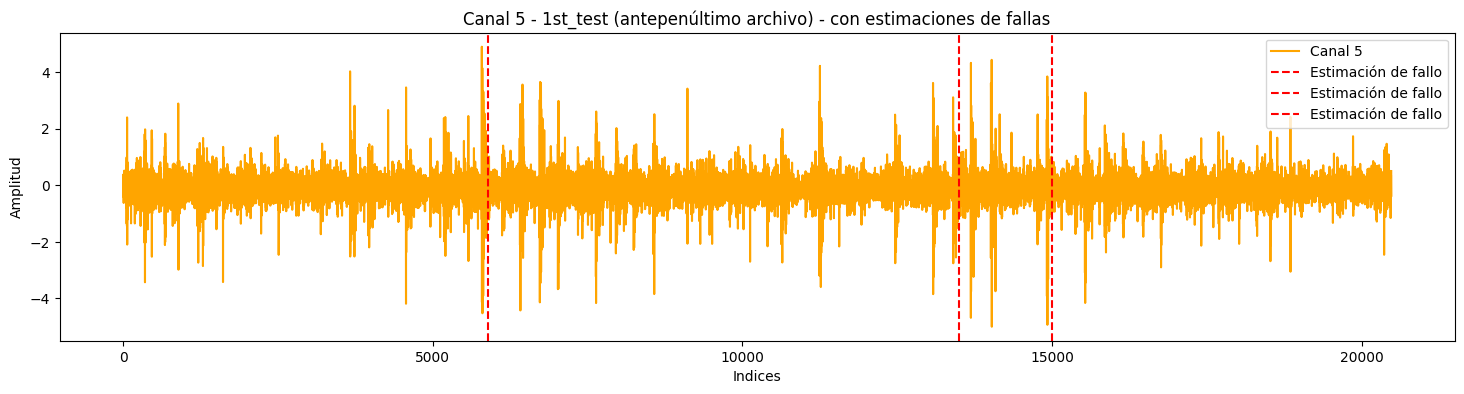

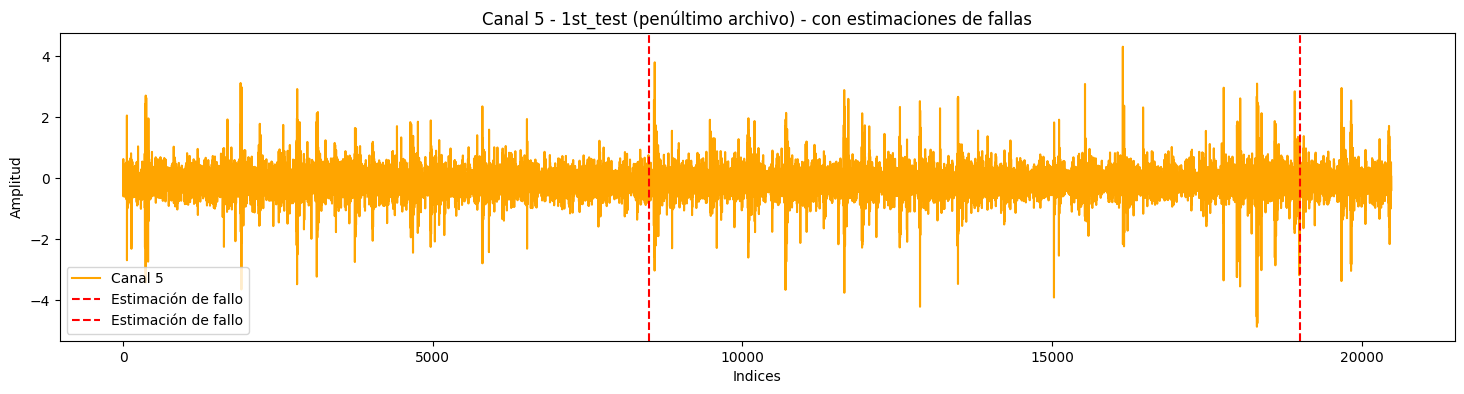

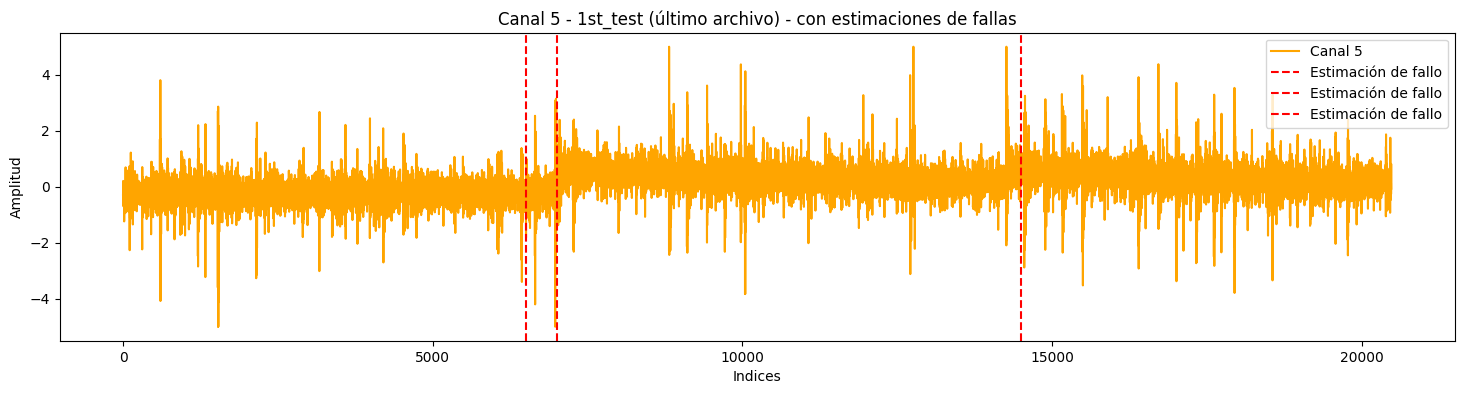

In [56]:
# Lecturas del canal 5 montado en el RODAMIENTO 3 (Falla en la pista interior)
dataset = cargar_archivo(f'{path_1st_test}/2003.11.25.23.19.56')
ax = dataset[['Canal 5']].plot(figsize=(18,4), color='orange')

# Gráfica de asintota vertical indicando una aproximación natural del fallo
ax.axvline(x=5900, color='red', linestyle='--', label='Estimación de fallo')
ax.axvline(x=15000, color='red', linestyle='--', label='Estimación de fallo')
ax.axvline(x=13500, color='red', linestyle='--', label='Estimación de fallo')

ax.legend()
plt.title('Canal 5 - 1st_test (antepenúltimo archivo) - con estimaciones de fallas')
plt.xlabel('Indices')
plt.ylabel('Amplitud')
plt.show()



dataset = cargar_archivo(f'{path_1st_test}/2003.11.25.23.29.56')
ax = dataset[['Canal 5']].plot(figsize=(18,4), color='orange')

# Gráfica de asintota vertical indicando una aproximación natural del fallo
ax.axvline(x=8500, color='red', linestyle='--', label='Estimación de fallo')
ax.axvline(x=19000, color='red', linestyle='--', label='Estimación de fallo')

ax.legend()
plt.title('Canal 5 - 1st_test (penúltimo archivo) - con estimaciones de fallas')
plt.xlabel('Indices')
plt.ylabel('Amplitud')
plt.show()

dataset = cargar_archivo(f'{path_1st_test}/2003.11.25.23.39.56')
ax = dataset[['Canal 5']].plot(figsize=(18,4), color='orange')

# Grafica de asintota vertical indicando una aproximación natural del fallo
ax.axvline(x=6500, color='red', linestyle='--', label='Estimación de fallo')
ax.axvline(x=7000, color='red', linestyle='--', label='Estimación de fallo')
ax.axvline(x=14500, color='red', linestyle='--', label='Estimación de fallo')

ax.legend()
plt.title('Canal 5 - 1st_test (último archivo) - con estimaciones de fallas')
plt.xlabel('Indices')
plt.ylabel('Amplitud')
plt.show()

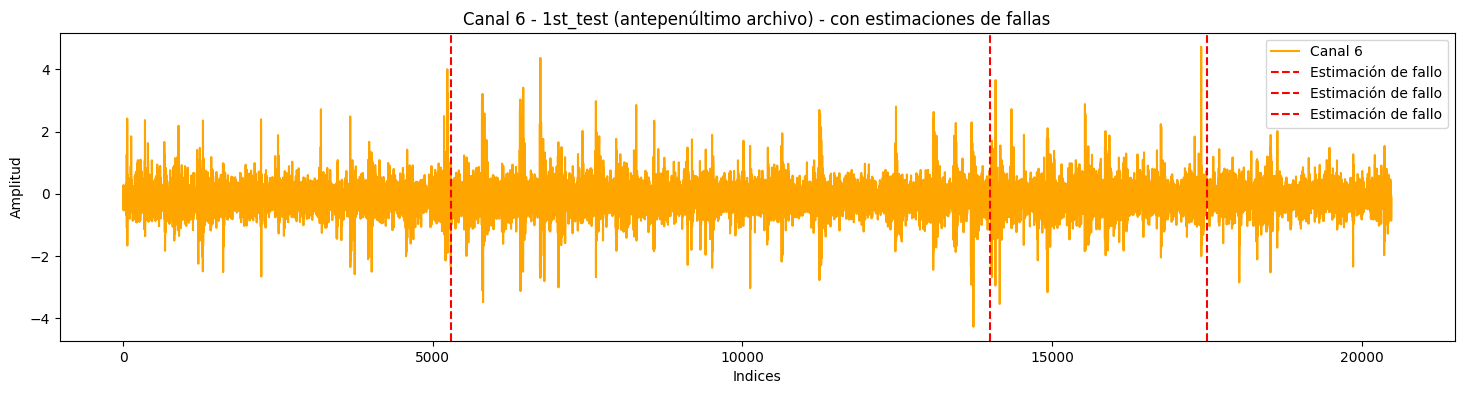

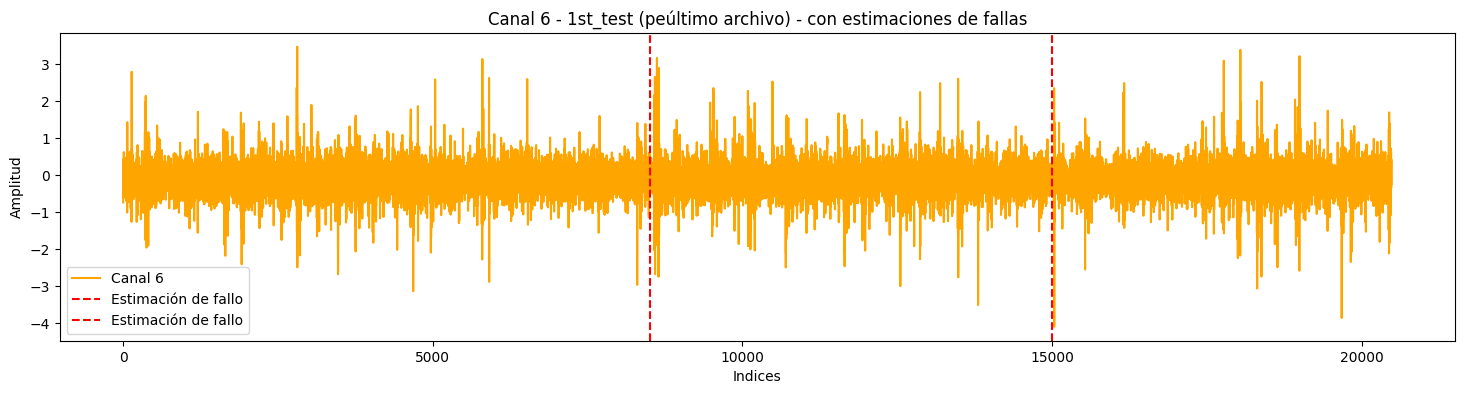

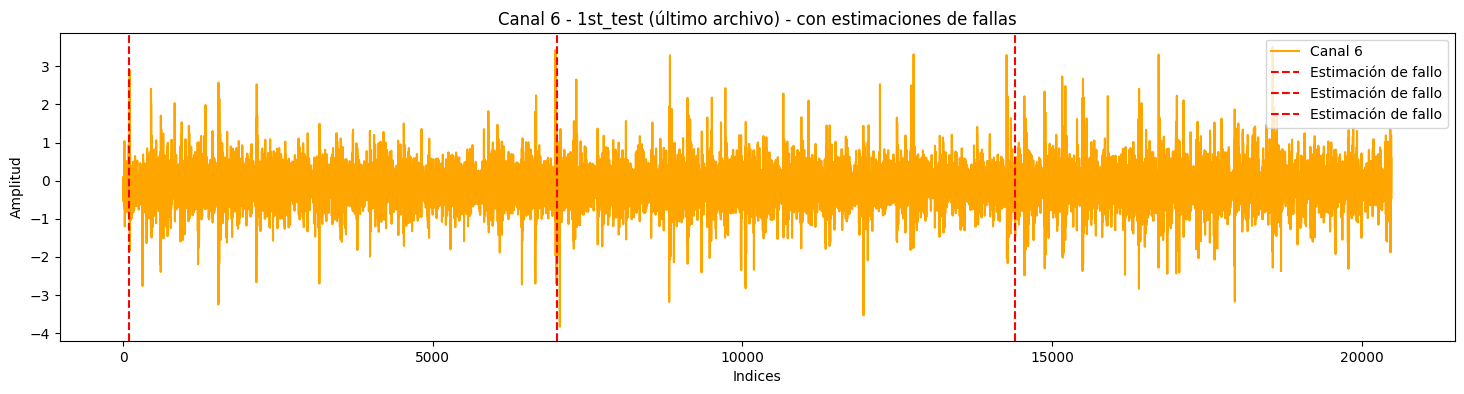

In [57]:
# Lecturas del canal 6 montado en el RODAMIENTO 3 (Falla en la pista interior)
dataset = cargar_archivo(f'{path_1st_test}/2003.11.25.23.19.56')
ax = dataset[['Canal 6']].plot(figsize=(18,4), color='orange')

# Gráfica de asintota vertical indicando una aproximación natural del fallo
ax.axvline(x=5300, color='red', linestyle='--', label='Estimación de fallo')
ax.axvline(x=14000, color='red', linestyle='--', label='Estimación de fallo')
ax.axvline(x=17500, color='red', linestyle='--', label='Estimación de fallo')

ax.legend()
plt.title('Canal 6 - 1st_test (antepenúltimo archivo) - con estimaciones de fallas')
plt.xlabel('Indices')
plt.ylabel('Amplitud')
plt.show()



dataset = cargar_archivo(f'{path_1st_test}/2003.11.25.23.29.56')
ax = dataset[['Canal 6']].plot(figsize=(18,4), color='orange')

# Gráfica de asintota vertical indicando una aproximación natural del fallo
ax.axvline(x=8500, color='red', linestyle='--', label='Estimación de fallo')
ax.axvline(x=15000, color='red', linestyle='--', label='Estimación de fallo')

ax.legend()
plt.title('Canal 6 - 1st_test (peúltimo archivo) - con estimaciones de fallas')
plt.xlabel('Indices')
plt.ylabel('Amplitud')
plt.show()

dataset = cargar_archivo(f'{path_1st_test}/2003.11.25.23.39.56')
ax = dataset[['Canal 6']].plot(figsize=(18,4), color='orange')

# Gráfica de asintota vertical indicando una aproximación natural del fallo
ax.axvline(x=100, color='red', linestyle='--', label='Estimación de fallo')
ax.axvline(x=7000, color='red', linestyle='--', label='Estimación de fallo')
ax.axvline(x=14400, color='red', linestyle='--', label='Estimación de fallo')

ax.legend()
plt.title('Canal 6 - 1st_test (último archivo) - con estimaciones de fallas')
plt.xlabel('Indices')
plt.ylabel('Amplitud')
plt.show()

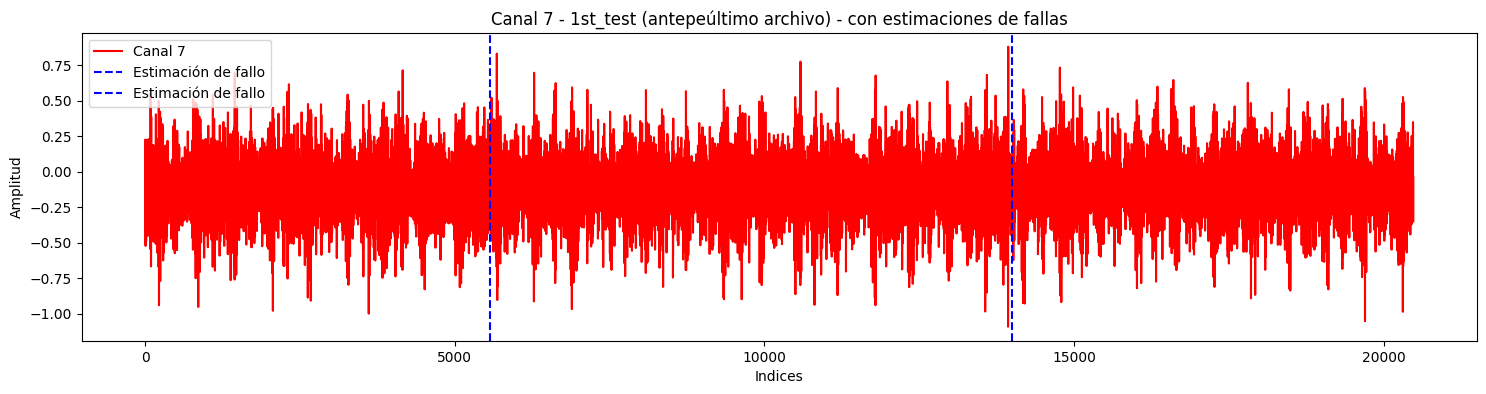

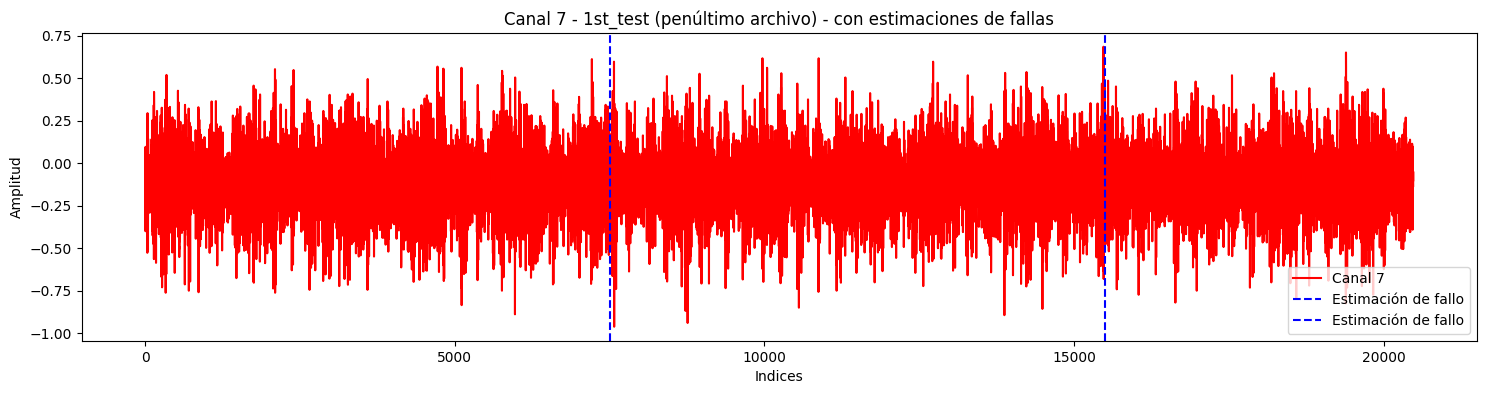

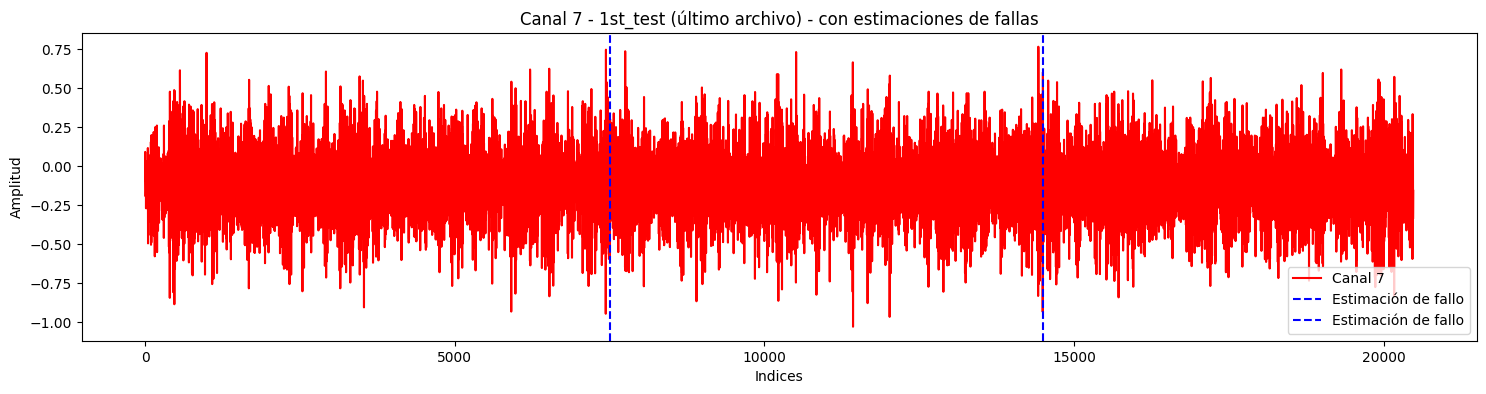

In [58]:
# Lecturas del canal 7 montado en el RODAMIENTO 4 (Falla en el elemento rodante)
dataset = cargar_archivo(f'{path_1st_test}/2003.11.25.23.19.56')
ax = dataset[['Canal 7']].plot(figsize=(18,4), color='red')

# Gráfica de asintota vertical indicando una aproximación natural del fallo
ax.axvline(x=5570, color='blue', linestyle='--', label='Estimación de fallo')
ax.axvline(x=14000, color='blue', linestyle='--', label='Estimación de fallo')

ax.legend()
plt.title('Canal 7 - 1st_test (antepeúltimo archivo) - con estimaciones de fallas')
plt.xlabel('Indices')
plt.ylabel('Amplitud')
plt.show()



dataset = cargar_archivo(f'{path_1st_test}/2003.11.25.23.29.56')
ax = dataset[['Canal 7']].plot(figsize=(18,4), color='red')

# Grafica de asintota vertical indicando una aproximación natural del fallo
ax.axvline(x=7500, color='blue', linestyle='--', label='Estimación de fallo')
ax.axvline(x=15500, color='blue', linestyle='--', label='Estimación de fallo')

ax.legend()
plt.title('Canal 7 - 1st_test (penúltimo archivo) - con estimaciones de fallas')
plt.xlabel('Indices')
plt.ylabel('Amplitud')
plt.show()

dataset = cargar_archivo(f'{path_1st_test}/2003.11.25.23.39.56')
ax = dataset[['Canal 7']].plot(figsize=(18,4), color='red')

# Grafica de asintota vertical indicando una aproximación natural del fallo
ax.axvline(x=7500, color='blue', linestyle='--', label='Estimación de fallo')
ax.axvline(x=14500, color='blue', linestyle='--', label='Estimación de fallo')

ax.legend()
plt.title('Canal 7 - 1st_test (último archivo) - con estimaciones de fallas')
plt.xlabel('Indices')
plt.ylabel('Amplitud')
plt.show()

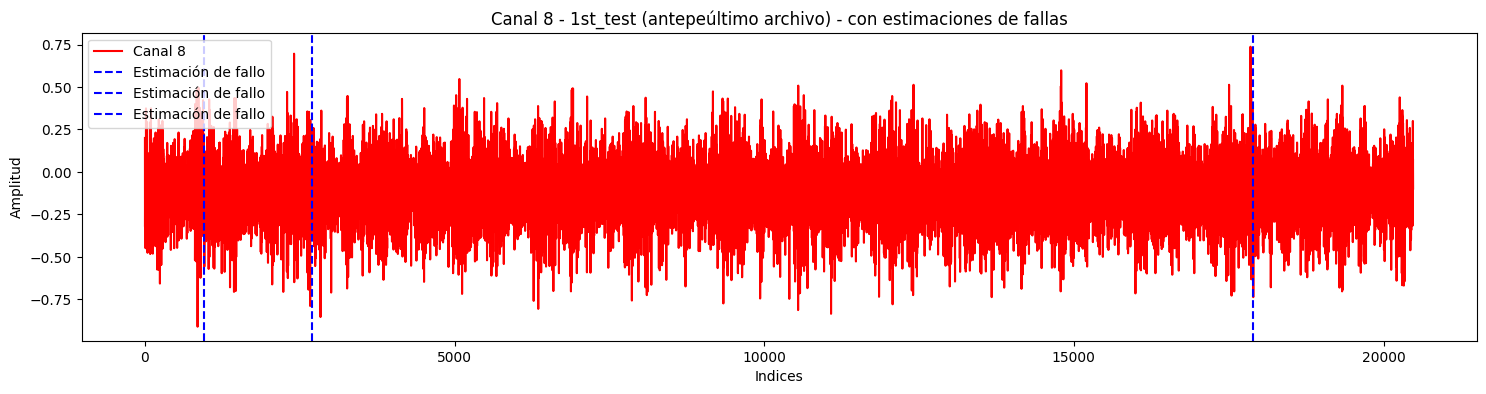

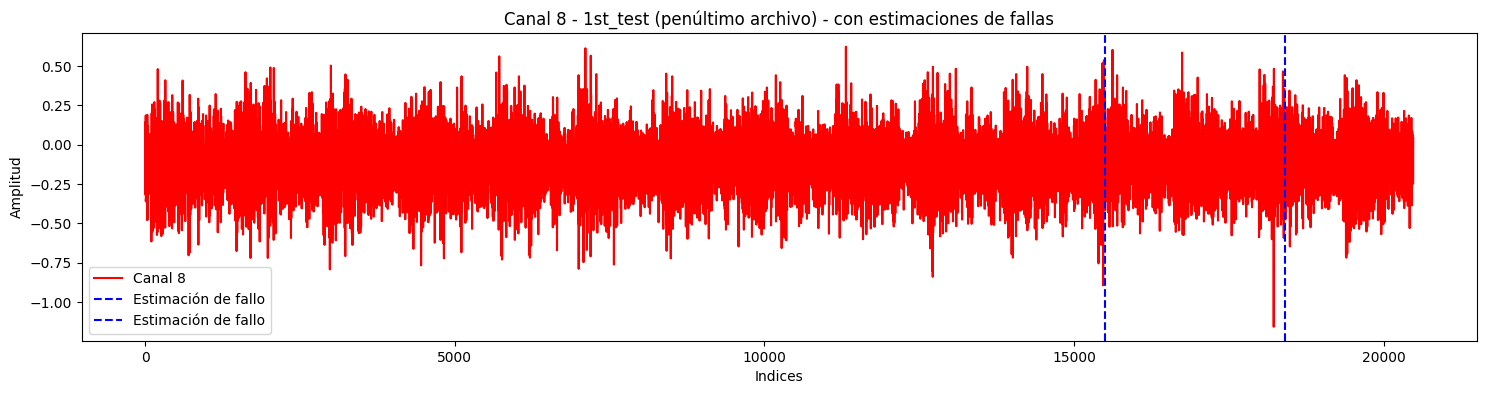

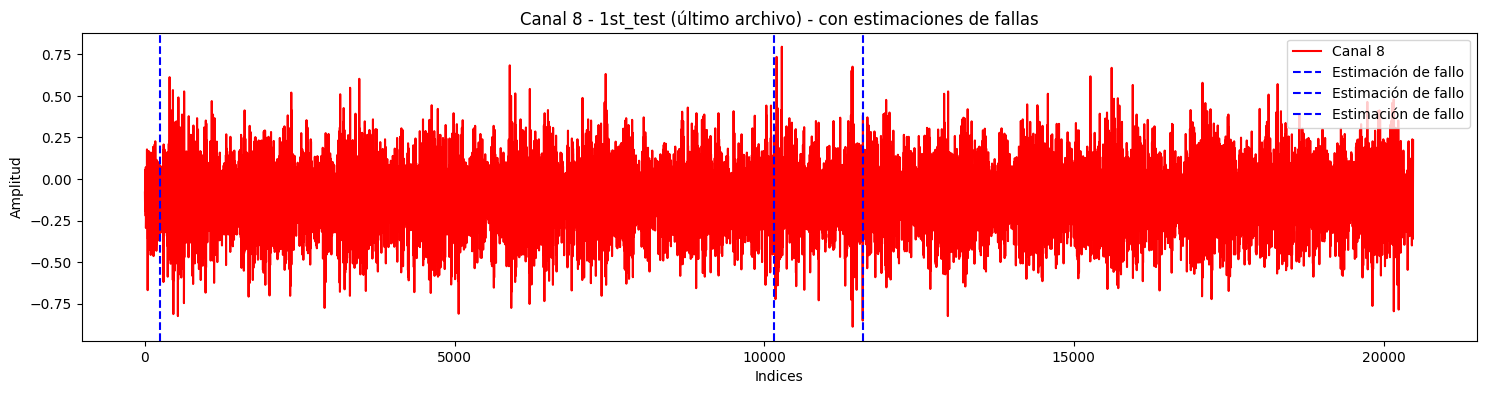

In [59]:
# Lecturas del canal 8 montado en el RODAMIENTO 4 (Falla en el elemento rodante)
dataset = cargar_archivo(f'{path_1st_test}/2003.11.25.23.19.56')
ax = dataset[['Canal 8']].plot(figsize=(18,4), color='red')

# Gráfica de asintota vertical indicando una aproximación natural del fallo
ax.axvline(x=950, color='blue', linestyle='--', label='Estimación de fallo')
ax.axvline(x=2700, color='blue', linestyle='--', label='Estimación de fallo')
ax.axvline(x=17900, color='blue', linestyle='--', label='Estimación de fallo')

ax.legend()
plt.title('Canal 8 - 1st_test (antepeúltimo archivo) - con estimaciones de fallas')
plt.xlabel('Indices')
plt.ylabel('Amplitud')
plt.show()



dataset = cargar_archivo(f'{path_1st_test}/2003.11.25.23.29.56')
ax = dataset[['Canal 8']].plot(figsize=(18,4), color='red')

# Grafica de asintota vertical indicando una aproximación natural del fallo
ax.axvline(x=15500, color='blue', linestyle='--', label='Estimación de fallo')
ax.axvline(x=18400, color='blue', linestyle='--', label='Estimación de fallo')

ax.legend()
plt.title('Canal 8 - 1st_test (penúltimo archivo) - con estimaciones de fallas')
plt.xlabel('Indices')
plt.ylabel('Amplitud')
plt.show()

dataset = cargar_archivo(f'{path_1st_test}/2003.11.25.23.39.56')
ax = dataset[['Canal 8']].plot(figsize=(18,4), color='red')

# Grafica de asintota vertical indicando una aproximación natural del fallo
ax.axvline(x=250, color='blue', linestyle='--', label='Estimación de fallo')
ax.axvline(x=10150, color='blue', linestyle='--', label='Estimación de fallo')
ax.axvline(x=11600, color='blue', linestyle='--', label='Estimación de fallo')

ax.legend()
plt.title('Canal 8 - 1st_test (último archivo) - con estimaciones de fallas')
plt.xlabel('Indices')
plt.ylabel('Amplitud')
plt.show()

## Gráficas de 2nd_test

En la prueba 2nd_test el rodamiento 1 presentó una falla en la pista exterior.


In [60]:
# Últimos 5 archivos en 2nd_test:
for file_name in copy_files_2nd_test[-5:]:
  print(file_name)

2004.02.19.05.42.39
2004.02.19.05.52.39
2004.02.19.06.02.39
2004.02.19.06.12.39
2004.02.19.06.22.39


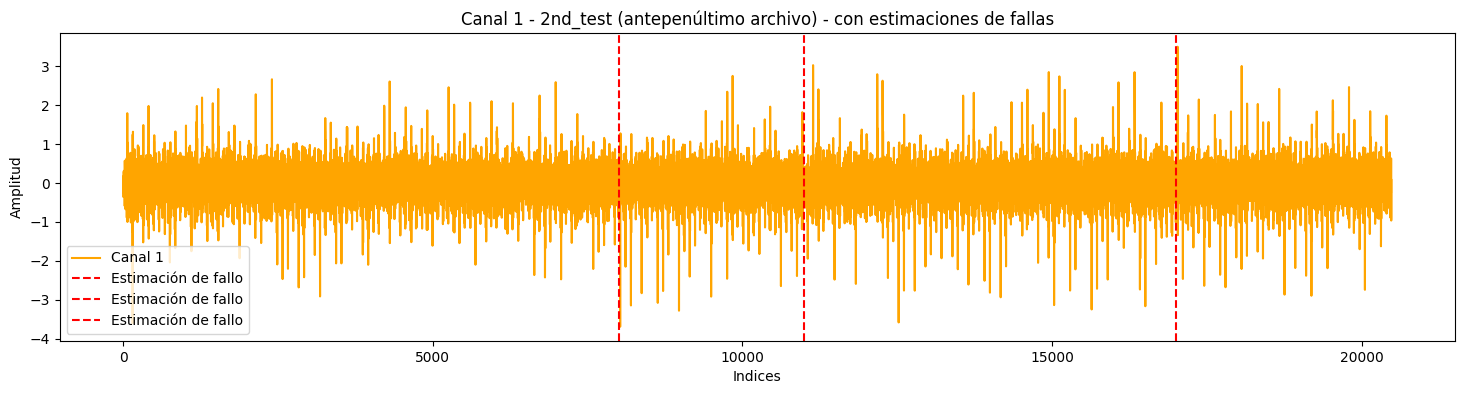

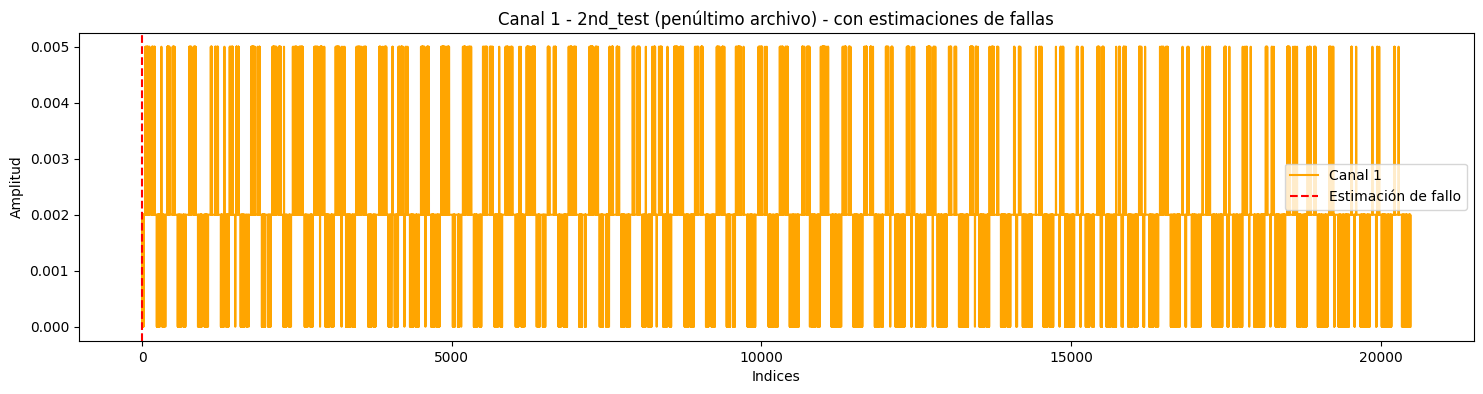

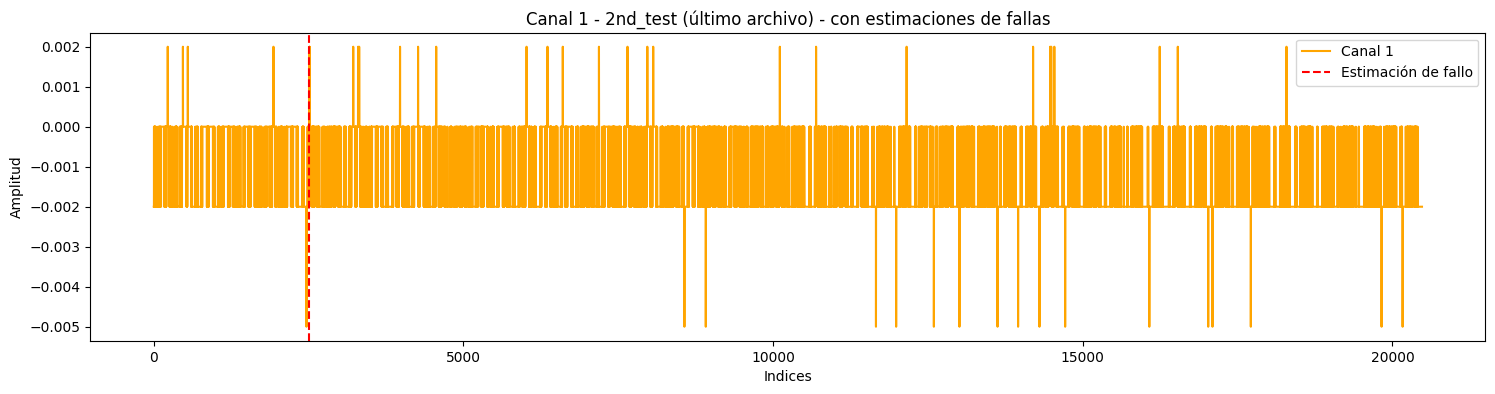

In [61]:
# Lecturas del canal 1 montado en el RODAMIENTO 1 (Falla en la pista exterior)
dataset = cargar_archivo(f'{path_2nd_test}/2004.02.19.06.02.39')
ax = dataset[['Canal 1']].plot(figsize=(18,4), color='orange')

# Grafica de asintota vertical indicando una aproximación natural del fallo
ax.axvline(x=8000, color='red', linestyle='--', label='Estimación de fallo')
ax.axvline(x=11000, color='red', linestyle='--', label='Estimación de fallo')
ax.axvline(x=17000, color='red', linestyle='--', label='Estimación de fallo')

ax.legend()
plt.title('Canal 1 - 2nd_test (antepenúltimo archivo) - con estimaciones de fallas')
plt.xlabel('Indices')
plt.ylabel('Amplitud')
plt.show()



dataset = cargar_archivo(f'{path_2nd_test}/2004.02.19.06.12.39')
ax = dataset[['Canal 1']].plot(figsize=(18,4), color='orange')

# Grafica de asintota vertical indicando una aproximación natural del fallo
ax.axvline(x=0, color='red', linestyle='--', label='Estimación de fallo')

ax.legend()
plt.title('Canal 1 - 2nd_test (penúltimo archivo) - con estimaciones de fallas')
plt.xlabel('Indices')
plt.ylabel('Amplitud')
plt.show()

dataset = cargar_archivo(f'{path_2nd_test}/2004.02.19.06.22.39')
ax = dataset[['Canal 1']].plot(figsize=(18,4), color='orange')

# Grafica de asintota vertical indicando una aproximación natural del fallo
ax.axvline(x=2500, color='red', linestyle='--', label='Estimación de fallo')

ax.legend()
plt.title('Canal 1 - 2nd_test (último archivo) - con estimaciones de fallas')
plt.xlabel('Indices')
plt.ylabel('Amplitud')
plt.show()

## Gráficas de 3rd_test

En la prueba 3th_test el rodamiento 3 presentó una falla en en al pista exterior.


In [62]:
# Últimos 5 archivos en 3rd_test:
for file_name in copy_files_3rd_test[-5:]:
  print(file_name)

2004.04.18.02.02.55
2004.04.18.02.12.55
2004.04.18.02.22.55
2004.04.18.02.32.55
2004.04.18.02.42.55


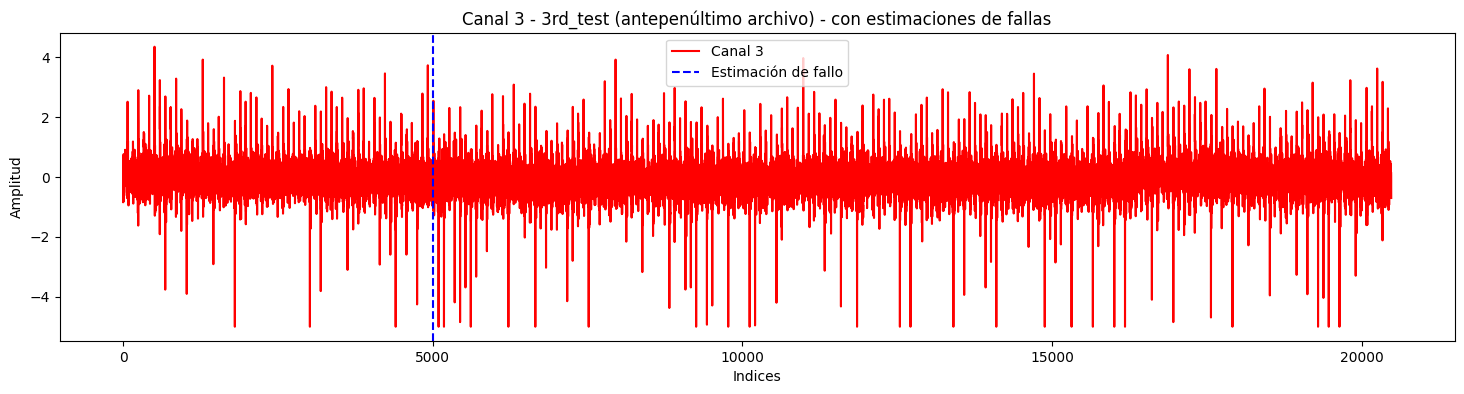

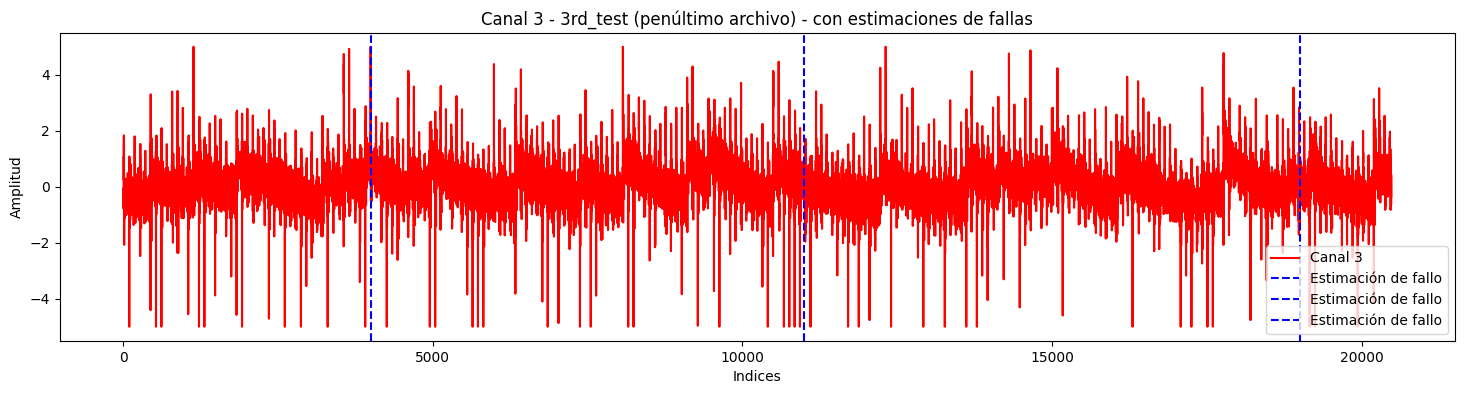

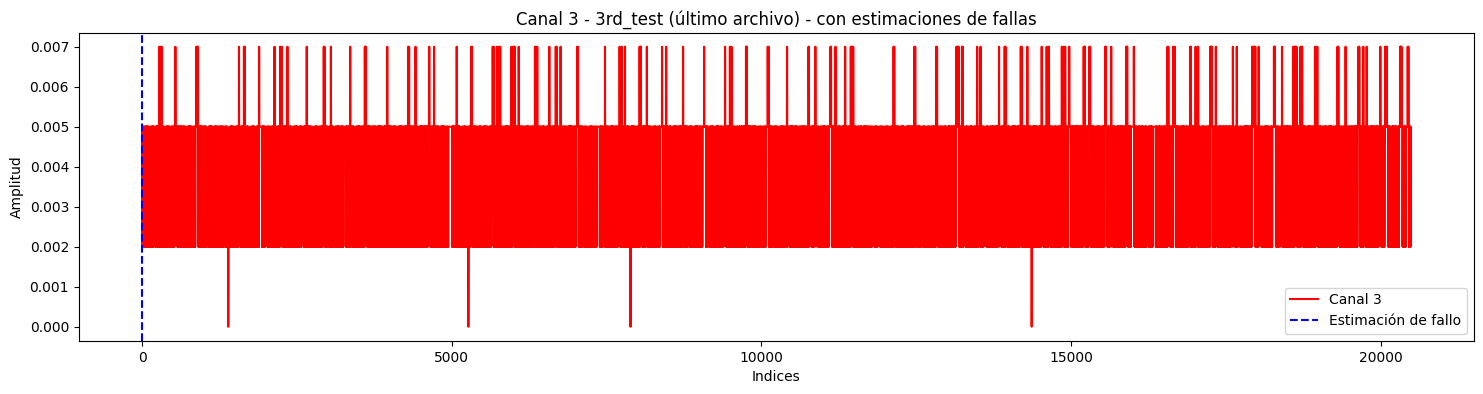

In [63]:
# Lecturas del canal 3 montado en el RODAMIENTO 3 (Falla en la pista exterior)
dataset = cargar_archivo(f'{path_3rd_test}/2004.04.18.02.22.55')
ax = dataset[['Canal 3']].plot(figsize=(18,4), color='red')

# Gráfica de asintota vertical indicando una aproximación natural del fallo
ax.axvline(x=5000, color='blue', linestyle='--', label='Estimación de fallo')

ax.legend()
plt.title('Canal 3 - 3rd_test (antepenúltimo archivo) - con estimaciones de fallas')
plt.xlabel('Indices')
plt.ylabel('Amplitud')
plt.show()



dataset = cargar_archivo(f'{path_3rd_test}/2004.04.18.02.32.55')
ax = dataset[['Canal 3']].plot(figsize=(18,4), color='red')

# Grafica de asintota vertical indicando una aproximación natural del fallo
ax.axvline(x=4000, color='blue', linestyle='--', label='Estimación de fallo')
ax.axvline(x=11000, color='blue', linestyle='--', label='Estimación de fallo')
ax.axvline(x=19000, color='blue', linestyle='--', label='Estimación de fallo')

ax.legend()
plt.title('Canal 3 - 3rd_test (penúltimo archivo) - con estimaciones de fallas')
plt.xlabel('Indices')
plt.ylabel('Amplitud')
plt.show()

dataset = cargar_archivo(f'{path_3rd_test}/2004.04.18.02.42.55')
ax = dataset[['Canal 3']].plot(figsize=(18,4), color='red')

# Grafica de asintota vertical indicando una aproximación natural del fallo
ax.axvline(x=0, color='blue', linestyle='--', label='Estimación de fallo')

ax.legend()
plt.title('Canal 3 - 3rd_test (último archivo) - con estimaciones de fallas')
plt.xlabel('Indices')
plt.ylabel('Amplitud')
plt.show()

## Análisis

En los experimentos 2nd_test y 3rd_test se puede observar que las señales cuadradas observadas sólo están presentes a final de los experimentos, sino que anterior a las señales cuadradas se puede ver una forma de señal con varios picos.

En las señales de los experimentos 1st_test y 2nd_test no se observa una tendencia clara que muestre la presencia de fallas en los rodamientos. Tampoco se puede diferencia a simple vista una modificacion en la señal en comparacion al estado incial de los experimentos.

En la señal creada con el penúltimo archivo del experimento 3rd_test se puede ver una clara modificación de la forma de la señal con respecto a un estado incial del experimento.



# Uso de filtros para resaltar fallas

Se procede a aplicar filtros para resaltar fallas en los datasets mas prometedores


## Filtros de wavelet

In [64]:
# prompt: aplica la decoposicion de wavelet a dataset[['Bearing 3']] y plotea el resultado

import matplotlib.pyplot as plt
import pywt

# Ensure the dataset is loaded correctly with the relevant column
# Based on the preceding code, dataset[['Bearing 3']] exists.
# If dataset was redefined later without 'Bearing 3', this might fail.
# Let's assume the last definition of `dataset` with 'Bearing 3' is the one we'll use.

# Apply DWT (Discrete Wavelet Transform)
# We'll use the 'db1' wavelet and perform a 1-level decomposition
# This will give us approximation and detail coefficients
coeffs = pywt.wavedec(dataset['Bearing 3'], 'db1', level=1)
cA1, cD1 = coeffs

# Plot the original signal, approximation coefficients, and detail coefficients
plt.figure(figsize=(18, 12))

plt.subplot(3, 1, 1)
plt.plot(dataset['Bearing 3'])
plt.title('Original Signal (Bearing 3)')
plt.ylabel('Amplitude')

plt.subplot(3, 1, 2)
plt.plot(cA1)
plt.title('Approximation Coefficients (Level 1)')
plt.ylabel('Amplitude')

plt.subplot(3, 1, 3)
plt.plot(cD1)
plt.title('Detail Coefficients (Level 1)')
plt.ylabel('Amplitude')
plt.xlabel('Sample Index')

plt.tight_layout()
plt.show()


KeyError: 'Bearing 3'

## Filtros de Fourier

# Otras cosas a validar

* analizar datos estadisticos similar a Miltos-90
* concatenar los archivos
  * promedios
  * crudos

  

* Buscar que estadisticos describen una senial cuadrada de una organica. determinar si hay mas seniales cuadradas
  * A recomendacion probar con varianza

* Considerar las graficas del 3er test para demostrar como se ve una senial en buen estado y una que no lo está

In [ ]:
import os
import pandas as pd


path_1st_test = '/content/1st_test/1st_test'
file_list_1st_test = os.listdir(path_1st_test)

file_data = []

print(f"Checking row counts for files in: {path_1st_test}")

for file_name in file_list_1st_test:
    file_path = os.path.join(path_1st_test, file_name)
    try:
        df = pd.read_csv(file_path, sep='\t', header=None) # Assuming no header and tab separation
        file_data.append({'archivo': file_name, 'longitud': len(df)})
    except Exception as e:
        print(f"Could not read file {file_name}: {e}")

file_lengths_df = pd.DataFrame(file_data)
print(file_lengths_df['longitud'].unique())

Checking row counts for files in: /content/1st_test/1st_test


,archivo,longitud
0,2003.11.16.16.18.46,20480
1,2003.10.31.07.19.46,20480
2,2003.10.31.12.21.44,20480
3,2003.10.22.20.04.13,20480
4,2003.11.07.18.01.44,20480


In [ ]:
import os
import pandas as pd

path_1st_test = '/content/1st_test/1st_test'
file_list_1st_test = os.listdir(path_1st_test)

print(f"Checking row counts for files in: {path_1st_test}")

for file_name in file_list_1st_test:
    file_path = os.path.join(path_1st_test, file_name)
    try:
        df = pd.read_csv(file_path, sep='\t', header=None) # Assuming no header and tab separation
        print(f"File: {file_name}, Rows: {len(df)}")
    except Exception as e:
        print(f"Could not read file {file_name}: {e}")